# C-MAPSS Turbofan Engine Degradation Dataset (FD001)
## Data Inspection, Preprocessing, Windowing, Baseline Autoencoder, Degradation Signal & Early Warning Analysis

**Author:** Mahtab  
**Branch:** `feat/mahtab`  
**Dataset:** NASA C-MAPSS FD001  

### Overview & Objectives
This notebook performs:
1. **Data Inspection & EDA (Steps 1–7)**: Initial data loading, validation, engine lifetime analysis, sensor variance analysis, sensor trend exploration, and operational settings inspection.
2. **Preprocessing Preparation (Steps 8–14)**: Sensor selection, model feature definition, healthy period definition (first 30% of lifetime), engine-level train/val split (80/20), data-leakage-free `StandardScaler` feature scaling, and post-scaling validation.
3. **Sequence Windowing (Steps 15–23)**: Sliding window configuration ($30 \text{ cycles} \times 14 \text{ sensors}$), safe per-engine window generation function, healthy train/val windows, full evaluation windows, window integrity assertions, and visual windowing demonstration.
4. **Baseline Autoencoder (Steps 24–31)**: Reproducible seed configuration, 420-feature input flattening, symmetric Dense Autoencoder architecture (420-128-64-32-64-128-420), training strictly on healthy training windows with EarlyStopping, training loss inspection, and healthy reconstruction error analysis.
5. **Degradation Signal Analysis (Steps 32–41)**: 95th-percentile healthy validation threshold definition (`0.521620`), full train and test trajectory scoring, true RUL timeline reconstruction, error vs. engine age trend exploration, error vs. RUL analysis, pooled/per-engine correlation analysis, and empirical degradation signal summary.
6. **Early Warning Analysis (Steps 42–50)**: Definition of Rule A (First Threshold Crossing) and Rule B (Persistent 5-Window Warning), early warning lead-time computation for full train and test engines, false-alarm analysis on healthy validation engines, lead-time distribution and timeline visualizations, CSV export of engine-level summaries, and empirical early warning findings.


### Environment, Path & Library Setup


In [1]:
import os
# Configure Keras backend to torch for cross-platform stability
os.environ['KERAS_BACKEND'] = 'torch'

import random
from pathlib import Path
import pandas as pd
import numpy as np
import scipy.stats as stats
import matplotlib.pyplot as plt
import keras
from keras.models import Sequential
from keras.layers import Dense, Input
from keras.optimizers import Adam
from keras.callbacks import EarlyStopping
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Set matplotlib parameters for clean visualizations
plt.rcParams['font.size'] = 10
plt.rcParams['figure.titlesize'] = 12
plt.rcParams['axes.labelsize'] = 10
plt.rcParams['axes.titlesize'] = 11

# Define PROJECT_ROOT robustly (works if executed from project root or notebooks directory)
current_dir = Path.cwd()
PROJECT_ROOT = current_dir.parent if current_dir.name == 'notebooks' else current_dir

# Output directories for saving figures and results
figures_dir = PROJECT_ROOT / 'reports' / 'figures' / 'mahtab'
figures_dir.mkdir(parents=True, exist_ok=True)

results_dir = PROJECT_ROOT / 'results' / 'mahtab'
results_dir.mkdir(parents=True, exist_ok=True)

print(f"Project Root: {PROJECT_ROOT}")
print(f"Figures Directory: {figures_dir}")
print(f"Results Directory: {results_dir}")
print(f"Keras Version: {keras.__version__} (Backend: {keras.backend.backend()})")


Project Root: C:\Users\mahta\AIdev\turbofan-failure-detection
Figures Directory: C:\Users\mahta\AIdev\turbofan-failure-detection\reports\figures\mahtab
Results Directory: C:\Users\mahta\AIdev\turbofan-failure-detection\results\mahtab
Keras Version: 3.14.0 (Backend: torch)


## STEP 1 — Load the Data

We load the three raw text files for FD001:
- `train_FD001.txt`
- `test_FD001.txt`
- `RUL_FD001.txt`

The dataset columns include engine unit number, cycle count, 3 operational settings, and 21 sensor measurements.


In [2]:
# Define column names
index_cols = ['unit_number', 'cycle']
setting_cols = ['operational_setting_1', 'operational_setting_2', 'operational_setting_3']
sensor_cols = [f'sensor_{i}' for i in range(1, 22)]
column_names = index_cols + setting_cols + sensor_cols

# Define file paths using pathlib
data_dir = PROJECT_ROOT / 'data' / 'raw'
train_file = data_dir / 'train_FD001.txt'
test_file = data_dir / 'test_FD001.txt'
rul_file = data_dir / 'RUL_FD001.txt'

# Verify files exist
for filepath in [train_file, test_file, rul_file]:
    if not filepath.exists():
        raise FileNotFoundError(f"Missing required dataset file: {filepath}")

# Load training and test data (whitespace-delimited)
train_df = pd.read_csv(train_file, sep=r'\s+', header=None, names=column_names)
test_df = pd.read_csv(test_file, sep=r'\s+', header=None, names=column_names)

# Load ground-truth RUL data for test engines
rul_df = pd.read_csv(rul_file, sep=r'\s+', header=None, names=['RUL'])

print("Data loaded successfully.")


Data loaded successfully.


## STEP 2 — Basic Data Validation

We run basic sanity checks on the training, test, and RUL datasets to verify shapes, data types, missing values, duplicates, engine counts, and cycle ranges.


In [3]:
# 1. Dataset Shapes
print("=== 1. Dataset Shapes ===")
print(f"Training data shape : {train_df.shape}")
print(f"Test data shape     : {test_df.shape}")
print(f"RUL data shape      : {rul_df.shape}")

# 2. First 5 rows of training data
print("\n=== 2. First 5 Rows of Training Data ===")
display(train_df.head())

# 3. Data Types
print("\n=== 3. Data Types Summary ===")
print(train_df.dtypes.value_counts())

# 4. Engine Counts
n_train_engines = train_df['unit_number'].nunique()
n_test_engines = test_df['unit_number'].nunique()
n_rul_values = len(rul_df)

print("\n=== 4. Unique Engine Counts ===")
print(f"Number of unique training engines : {n_train_engines}")
print(f"Number of unique test engines     : {n_test_engines}")
print(f"Number of RUL entries             : {n_rul_values}")

# 5. Missing Values & Duplicates
train_missing = train_df.isnull().sum().sum()
test_missing = test_df.isnull().sum().sum()
rul_missing = rul_df.isnull().sum().sum()

train_duplicates = train_df.duplicated().sum()
test_duplicates = test_df.duplicated().sum()

print("\n=== 5. Data Quality Checks ===")
print(f"Missing values - Train: {train_missing}, Test: {test_missing}, RUL: {rul_missing}")
print(f"Duplicate rows - Train: {train_duplicates}, Test: {test_duplicates}")

# 6. Cycle Ranges
print("\n=== 6. Cycle Number Ranges ===")
print(f"Train cycle range : {train_df['cycle'].min()} to {train_df['cycle'].max()}")
print(f"Test cycle range  : {test_df['cycle'].min()} to {test_df['cycle'].max()}")

# 7. Total Columns
print(f"Total columns     : {train_df.shape[1]}")

# Assertions for expected FD001 counts
assert train_df.shape == (20631, 26), f"Unexpected train shape: {train_df.shape}"
assert test_df.shape == (13096, 26), f"Unexpected test shape: {test_df.shape}"
assert rul_df.shape == (100, 1), f"Unexpected RUL shape: {rul_df.shape}"

assert n_train_engines == 100, f"Expected 100 training engines, found {n_train_engines}"
assert n_test_engines == 100, f"Expected 100 test engines, found {n_test_engines}"
assert n_rul_values == 100, f"Expected 100 RUL values, found {n_rul_values}"

assert train_missing == 0 and test_missing == 0 and rul_missing == 0, "Missing values detected!"
assert train_duplicates == 0 and test_duplicates == 0, "Duplicate rows detected!"

print("\nValidation passed successfully: All engine counts, cycle ranges, and data integrity checks match expected FD001 properties.")


=== 1. Dataset Shapes ===
Training data shape : (20631, 26)
Test data shape     : (13096, 26)
RUL data shape      : (100, 1)

=== 2. First 5 Rows of Training Data ===


,unit_number,cycle,operational_setting_1,operational_setting_2,operational_setting_3,sensor_1,sensor_2,sensor_3,sensor_4,sensor_5,...,sensor_12,sensor_13,sensor_14,sensor_15,sensor_16,sensor_17,sensor_18,sensor_19,sensor_20,sensor_21
0,1,1,-0.0007,-0.0004,100.0,518.67,641.82,1589.70,1400.60,14.62,...,521.66,2388.02,8138.62,8.4195,0.03,392,2388,100.0,39.06,23.4190
1,1,2,0.0019,-0.0003,100.0,518.67,642.15,1591.82,1403.14,14.62,...,522.28,2388.07,8131.49,8.4318,0.03,392,2388,100.0,39.00,23.4236
2,1,3,-0.0043,0.0003,100.0,518.67,642.35,1587.99,1404.20,14.62,...,522.42,2388.03,8133.23,8.4178,0.03,390,2388,100.0,38.95,23.3442
3,1,4,0.0007,0.0000,100.0,518.67,642.35,1582.79,1401.87,14.62,...,522.86,2388.08,8133.83,8.3682,0.03,392,2388,100.0,38.88,23.3739
4,1,5,-0.0019,-0.0002,100.0,518.67,642.37,1582.85,1406.22,14.62,...,522.19,2388.04,8133.80,8.4294,0.03,393,2388,100.0,38.90,23.4044



=== 3. Data Types Summary ===
float64    22
int64       4
Name: count, dtype: int64

=== 4. Unique Engine Counts ===
Number of unique training engines : 100
Number of unique test engines     : 100
Number of RUL entries             : 100

=== 5. Data Quality Checks ===
Missing values - Train: 0, Test: 0, RUL: 0
Duplicate rows - Train: 0, Test: 0

=== 6. Cycle Number Ranges ===
Train cycle range : 1 to 362
Test cycle range  : 1 to 303
Total columns     : 26

Validation passed successfully: All engine counts, cycle ranges, and data integrity checks match expected FD001 properties.


## STEP 3 — Engine Lifetime Analysis

For each training engine, we calculate its total lifetime (maximum cycle reached before failure). Trajectories in the training set run continuously until complete system failure.


=== Training Engine Lifetime Statistics ===
Minimum Lifetime : 128 cycles
Maximum Lifetime : 362 cycles
Mean Lifetime    : 206.31 cycles
Median Lifetime  : 199.0 cycles


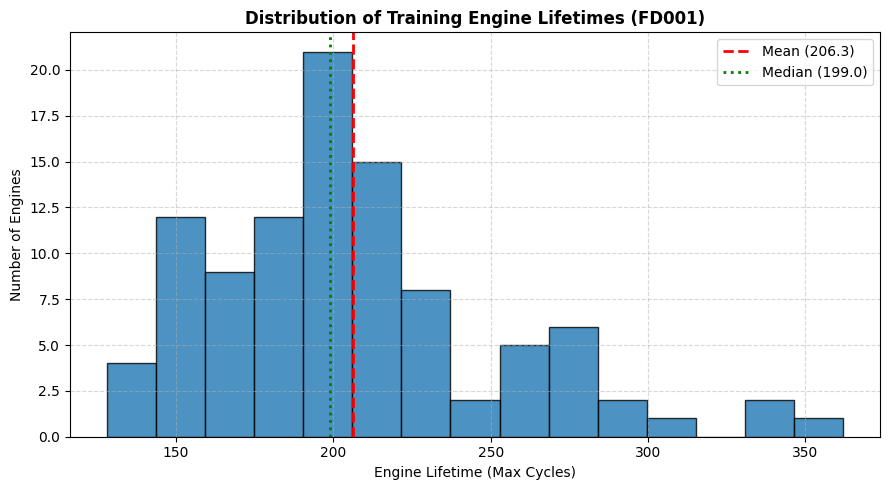

Saved figure to: C:\Users\mahta\AIdev\turbofan-failure-detection\reports\figures\mahtab\engine_lifetimes.png


In [4]:
# Calculate maximum cycle for each training engine
engine_lifetimes = train_df.groupby('unit_number')['cycle'].max()

# Summary statistics
min_lifetime = engine_lifetimes.min()
max_lifetime = engine_lifetimes.max()
mean_lifetime = engine_lifetimes.mean()
median_lifetime = engine_lifetimes.median()

print("=== Training Engine Lifetime Statistics ===")
print(f"Minimum Lifetime : {min_lifetime} cycles")
print(f"Maximum Lifetime : {max_lifetime} cycles")
print(f"Mean Lifetime    : {mean_lifetime:.2f} cycles")
print(f"Median Lifetime  : {median_lifetime:.1f} cycles")

# Assertions for expected lifetime statistics
assert min_lifetime == 128, f"Expected min lifetime 128, got {min_lifetime}"
assert max_lifetime == 362, f"Expected max lifetime 362, got {max_lifetime}"
assert np.isclose(mean_lifetime, 206.31, atol=0.01), f"Expected mean lifetime ~206.31, got {mean_lifetime}"
assert median_lifetime == 199.0, f"Expected median lifetime 199.0, got {median_lifetime}"

# Histogram of training engine lifetimes
plt.figure(figsize=(9, 5))
plt.hist(engine_lifetimes, bins=15, color='#1f77b4', edgecolor='black', alpha=0.8)
plt.axvline(mean_lifetime, color='red', linestyle='--', linewidth=2, label=f'Mean ({mean_lifetime:.1f})')
plt.axvline(median_lifetime, color='green', linestyle=':', linewidth=2, label=f'Median ({median_lifetime:.1f})')

plt.title('Distribution of Training Engine Lifetimes (FD001)', fontsize=12, fontweight='bold')
plt.xlabel('Engine Lifetime (Max Cycles)', fontsize=10)
plt.ylabel('Number of Engines', fontsize=10)
plt.legend(loc='upper right')
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()

# Save figure
lifetime_fig_path = figures_dir / 'engine_lifetimes.png'
plt.savefig(lifetime_fig_path, dpi=300)
plt.show()

print(f"Saved figure to: {lifetime_fig_path}")


## STEP 4 — Sensor Variance Analysis

We evaluate all 21 sensors (`sensor_1` through `sensor_21`) on the training dataset to compute:
- Variance
- Standard deviation
- Number of unique values

This allows us to identify sensors that remain constant or nearly constant throughout engine runtimes.


=== Sensor Variance & Uniqueness Table (Sorted by Variance) ===


,sensor,variance,std_dev,n_unique
0,sensor_1,0.000000e+00,0.000000e+00,1
1,sensor_10,0.000000e+00,0.000000e+00,1
2,sensor_19,0.000000e+00,0.000000e+00,1
3,sensor_18,0.000000e+00,0.000000e+00,1
4,sensor_16,1.203765e-35,3.469531e-18,1
5,sensor_5,2.840037e-29,5.329200e-15,1
6,sensor_6,1.929279e-06,1.388985e-03,2
7,sensor_15,1.406628e-03,3.750504e-02,1918
8,sensor_8,5.038938e-03,7.098548e-02,53
9,sensor_13,5.172330e-03,7.191892e-02,56


Constant sensors (exactly 1 unique value, var=0) : ['sensor_1', 'sensor_10', 'sensor_19', 'sensor_18', 'sensor_16', 'sensor_5']
Nearly constant sensors (2 unique values, low var) : ['sensor_6']


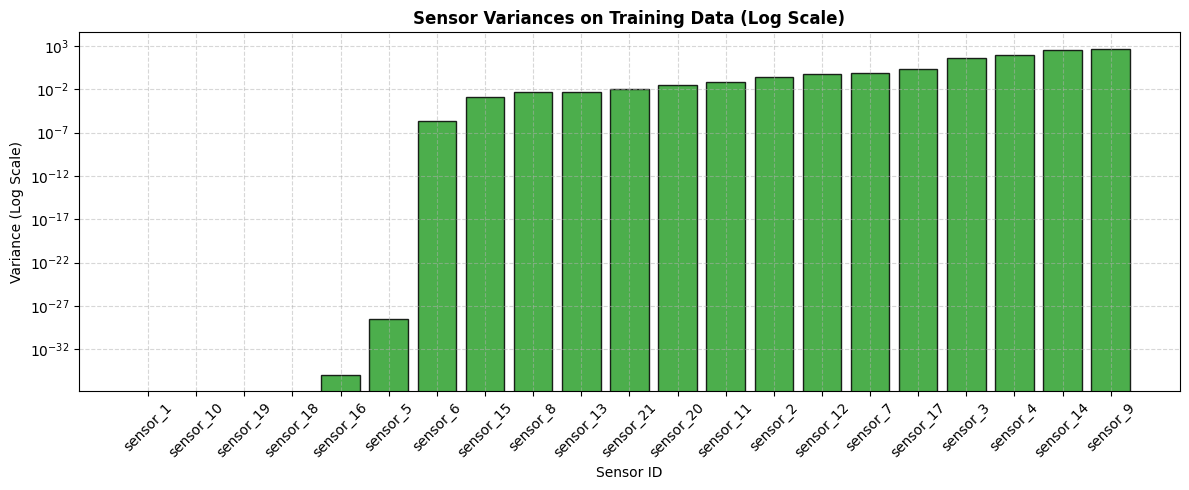

Saved figure to: C:\Users\mahta\AIdev\turbofan-failure-detection\reports\figures\mahtab\sensor_variance.png


In [5]:
# Compute statistics for each sensor
sensor_stats_list = []

for sensor in sensor_cols:
    var_val = train_df[sensor].var()
    std_val = train_df[sensor].std()
    unique_val = train_df[sensor].nunique()
    sensor_stats_list.append({
        'sensor': sensor,
        'variance': var_val,
        'std_dev': std_val,
        'n_unique': unique_val
    })

# Sorted dataframe from lowest variance to highest variance
sensor_variance_df = pd.DataFrame(sensor_stats_list).sort_values(by='variance', ascending=True).reset_index(drop=True)

print("=== Sensor Variance & Uniqueness Table (Sorted by Variance) ===")
display(sensor_variance_df)

# Identify constant and nearly constant sensors
constant_sensors = sensor_variance_df[sensor_variance_df['n_unique'] == 1]['sensor'].tolist()
nearly_constant_sensors = sensor_variance_df[(sensor_variance_df['n_unique'] > 1) & (sensor_variance_df['variance'] < 1e-4)]['sensor'].tolist()

print(f"Constant sensors (exactly 1 unique value, var=0) : {constant_sensors}")
print(f"Nearly constant sensors (2 unique values, low var) : {nearly_constant_sensors}")

# Create bar chart showing sensor variances
plt.figure(figsize=(12, 5))
bars = plt.bar(sensor_variance_df['sensor'], sensor_variance_df['variance'], color='#2ca02c', edgecolor='black', alpha=0.85)

# Use logarithmic scale on y-axis due to wide range of variance values
plt.yscale('log')
plt.title('Sensor Variances on Training Data (Log Scale)', fontsize=12, fontweight='bold')
plt.xlabel('Sensor ID', fontsize=10)
plt.ylabel('Variance (Log Scale)', fontsize=10)
plt.xticks(rotation=45)
plt.grid(True, which='both', linestyle='--', alpha=0.5)
plt.tight_layout()

# Save figure
variance_fig_path = figures_dir / 'sensor_variance.png'
plt.savefig(variance_fig_path, dpi=300)
plt.show()

print(f"Saved figure to: {variance_fig_path}")


## STEP 5 — Sensor Trend Exploration

Based directly on the empirical EDA findings in Step 4:
- We exclude constant sensors (`sensor_1`, `sensor_5`, `sensor_10`, `sensor_16`, `sensor_18`, `sensor_19`) and nearly constant sensors (`sensor_6`).
- We select a representative set of sensors across different non-zero variance scales:
  - **Low/Moderate Variance**: `sensor_7`, `sensor_11`, `sensor_12`, `sensor_15`, `sensor_21`
  - **High Variance**: `sensor_2`, `sensor_3`, `sensor_4`, `sensor_14`

Below we plot these selected sensors over operating cycles for example training engines (Units 1, 2, 3, 4) to visually inspect sensor behavior over engine cycles.
Subplot titles format variances using `.4g` precision to avoid displaying small non-zero variances as `0.00`.


=== STEP 5: SENSOR SELECTION RATIONALE ===
Selected sensors for trend exploration:
  - sensor_2: Variance = 0.2501, Unique Values = 310 -> Non-constant sensor with meaningful variation
  - sensor_3: Variance = 37.59, Unique Values = 3012 -> Non-constant sensor with meaningful variation
  - sensor_4: Variance = 81.01, Unique Values = 4051 -> Non-constant sensor with meaningful variation
  - sensor_7: Variance = 0.7834, Unique Values = 513 -> Non-constant sensor with meaningful variation
  - sensor_11: Variance = 0.07134, Unique Values = 159 -> Non-constant sensor with meaningful variation
  - sensor_12: Variance = 0.544, Unique Values = 427 -> Non-constant sensor with meaningful variation
  - sensor_14: Variance = 363.9, Unique Values = 6078 -> Non-constant sensor with meaningful variation
  - sensor_15: Variance = 0.001407, Unique Values = 1918 -> Non-constant sensor with meaningful variation


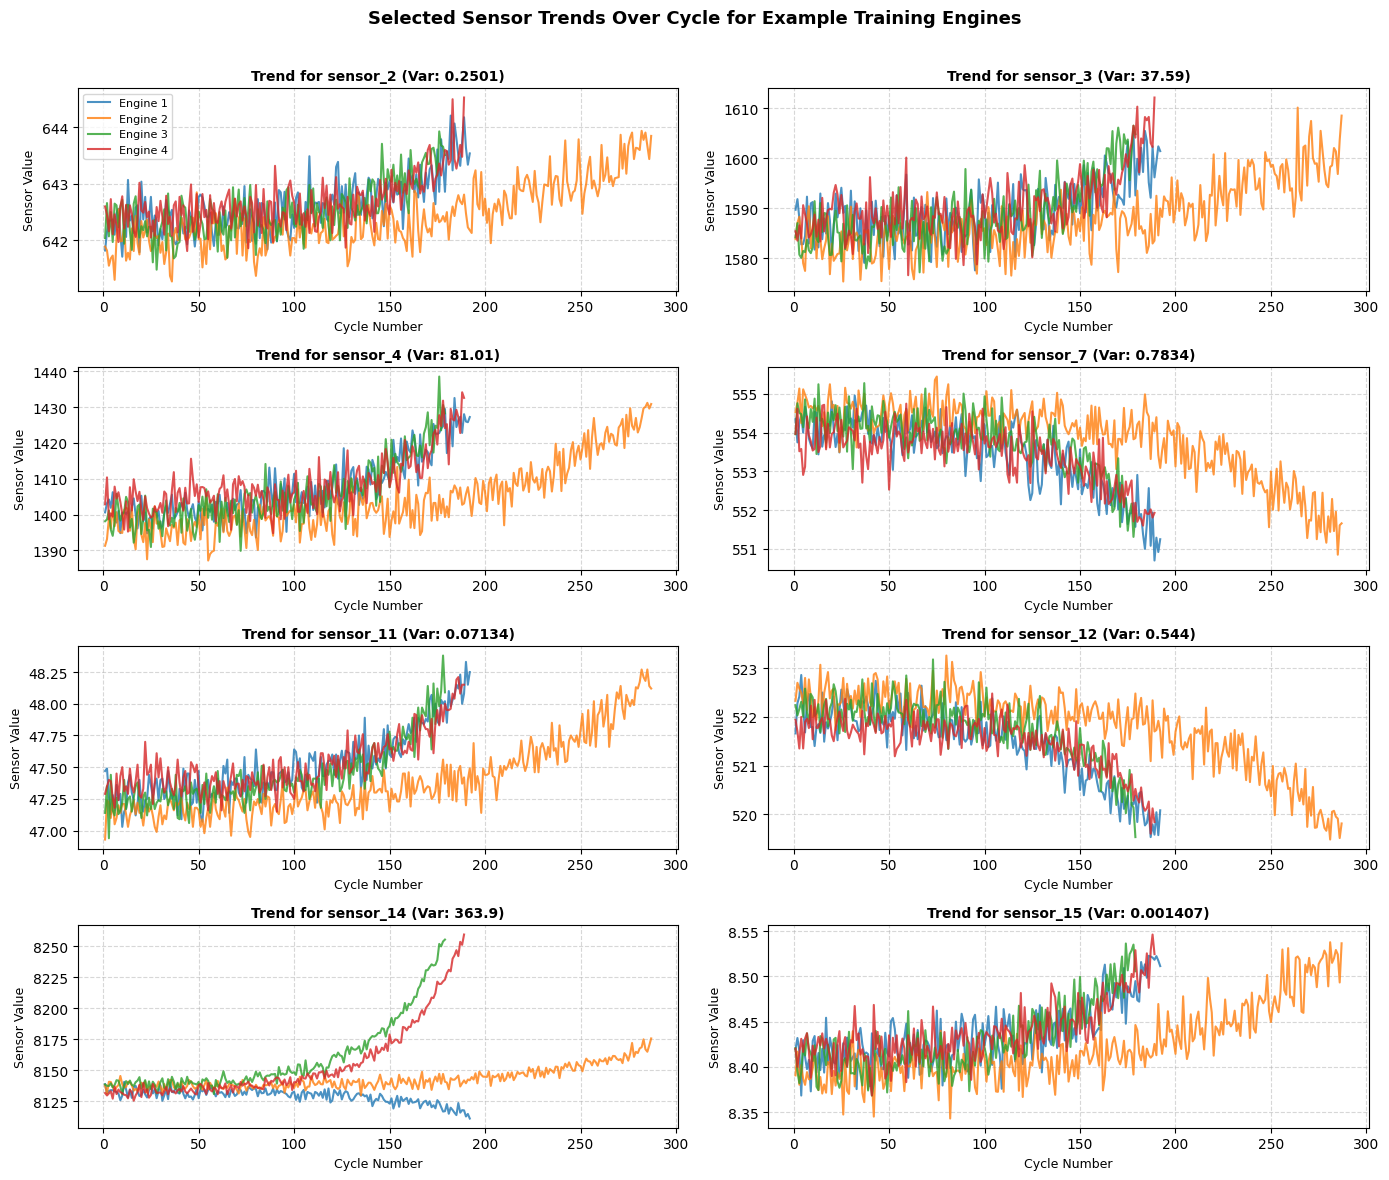

Saved figure to: C:\Users\mahta\AIdev\turbofan-failure-detection\reports\figures\mahtab\example_sensor_trends.png


In [6]:
# Representative sensors selected purely based on Step 4 EDA evidence
selected_sensors = ['sensor_2', 'sensor_3', 'sensor_4', 'sensor_7', 'sensor_11', 'sensor_12', 'sensor_14', 'sensor_15']

print("=== STEP 5: SENSOR SELECTION RATIONALE ===")
print("Selected sensors for trend exploration:")
for s in selected_sensors:
    row = sensor_variance_df[sensor_variance_df['sensor'] == s].iloc[0]
    print(f"  - {s}: Variance = {row['variance']:.4g}, Unique Values = {row['n_unique']} -> Non-constant sensor with meaningful variation")

# Example engines to plot
example_units = [1, 2, 3, 4]

# Plot sensor trends over cycle
fig, axes = plt.subplots(nrows=4, ncols=2, figsize=(14, 12), sharex=False)
axes = axes.flatten()

for idx, sensor in enumerate(selected_sensors):
    ax = axes[idx]
    for unit in example_units:
        unit_data = train_df[train_df['unit_number'] == unit]
        ax.plot(unit_data['cycle'], unit_data[sensor], label=f'Engine {unit}', alpha=0.8, linewidth=1.5)
    
    # Use .4g precision to avoid displaying small non-zero variances as 0.00 (e.g. sensor_15)
    sensor_var = train_df[sensor].var()
    ax.set_title(f'Trend for {sensor} (Var: {sensor_var:.4g})', fontsize=10, fontweight='bold')
    ax.set_xlabel('Cycle Number', fontsize=9)
    ax.set_ylabel('Sensor Value', fontsize=9)
    ax.grid(True, linestyle='--', alpha=0.5)
    if idx == 0:
        ax.legend(loc='best', fontsize=8)

plt.suptitle('Selected Sensor Trends Over Cycle for Example Training Engines', fontsize=13, fontweight='bold')
plt.tight_layout(rect=[0, 0, 1, 0.97])

# Save figure
trends_fig_path = figures_dir / 'example_sensor_trends.png'
plt.savefig(trends_fig_path, dpi=300)
plt.show()

print(f"Saved figure to: {trends_fig_path}")


## STEP 6 — Operational Settings Inspection

We inspect the three operational setting columns (`operational_setting_1`, `operational_setting_2`, `operational_setting_3`) to verify the operational conditions of dataset FD001.


In [7]:
op_settings = ['operational_setting_1', 'operational_setting_2', 'operational_setting_3']
op_summary_list = []

for op in op_settings:
    op_summary_list.append({
        'setting': op,
        'variance': train_df[op].var(),
        'std_dev': train_df[op].std(),
        'n_unique': train_df[op].nunique(),
        'min': train_df[op].min(),
        'max': train_df[op].max()
    })

op_summary_df = pd.DataFrame(op_summary_list)
print("=== Operational Settings Summary ===")
display(op_summary_df)

print("\n=== Operational Setting Analysis & Interpretation ===")
print("1. operational_setting_3 is completely constant (value=100.0, variance=0, n_unique=1).")
print("2. operational_setting_1 and operational_setting_2 show minimal fluctuations around zero (std of 0.0022 and 0.00029 respectively).")
print("3. Conclusion: The data empirically confirms that FD001 operates under a SINGLE operating condition (sea-level condition with slight environmental noise).")


=== Operational Settings Summary ===


,setting,variance,std_dev,n_unique,min,max
0,operational_setting_1,4.784340e-06,0.002187,158,-0.0087,0.0087
1,operational_setting_2,8.588541e-08,0.000293,13,-0.0006,0.0006
2,operational_setting_3,0.000000e+00,0.000000,1,100.0000,100.0000



=== Operational Setting Analysis & Interpretation ===
1. operational_setting_3 is completely constant (value=100.0, variance=0, n_unique=1).
2. operational_setting_1 and operational_setting_2 show minimal fluctuations around zero (std of 0.0022 and 0.00029 respectively).
3. Conclusion: The data empirically confirms that FD001 operates under a SINGLE operating condition (sea-level condition with slight environmental noise).


## EDA Findings

Below is a concise summary of the empirical findings from our exploratory data analysis of dataset **FD001**:

1. **Dataset Dimensions**:
   - **Training set (`train_FD001.txt`)**: 20,631 rows × 26 columns
   - **Test set (`test_FD001.txt`)**: 13,096 rows × 26 columns
   - **RUL targets (`RUL_FD001.txt`)**: 100 rows × 1 column

2. **Engine Counts**:
   - Exactly **100 training engines** (run until failure).
   - Exactly **100 test engines** (stopped prior to failure).
   - Exactly **100 ground-truth RUL values** corresponding to test engines.

3. **Engine Lifetime Statistics (Training Set)**:
   - **Minimum Lifetime**: 128 cycles
   - **Maximum Lifetime**: 362 cycles
   - **Mean Lifetime**: 206.31 cycles
   - **Median Lifetime**: 199.0 cycles

4. **Data Integrity & Quality**:
   - **Missing values**: 0 missing values across all files.
   - **Duplicates**: 0 duplicate rows detected.

5. **Sensor Variation & Candidate Removal Analysis**:
   - **Constant sensors (6 total)** — exactly 1 unique value, variance = 0:
     - `sensor_1`, `sensor_5`, `sensor_10`, `sensor_16`, `sensor_18`, `sensor_19`
   - **Nearly constant sensor (1 total)** — only 2 unique values and extremely low variance ($1.93 \times 10^{-6}$):
     - `sensor_6`
   - *Note*: None of these 7 sensors have been removed from raw DataFrames. They are identified as candidates for removal in the preprocessing steps.
   - **Informative sensors with meaningful variation (14 total)**:
     - `sensor_2`, `sensor_3`, `sensor_4`, `sensor_7`, `sensor_8`, `sensor_9`, `sensor_11`, `sensor_12`, `sensor_13`, `sensor_14`, `sensor_15`, `sensor_17`, `sensor_20`, `sensor_21`.

6. **Operational Settings Observation**:
   - `operational_setting_3` is constant ($100.0$).
   - `operational_setting_1` and `operational_setting_2` fluctuate minimally within $[-0.0087, 0.0087]$ and $[-0.0006, 0.0006]$.
   - This confirms empirically that dataset FD001 operates under **one single operating condition**.


## STEP 8 — Sensor Selection

Based directly on the empirical EDA variance and uniqueness analysis in Step 4, we exclude the 7 sensors that provide little or no variation:
- **Exactly constant sensors (6)**: `sensor_1`, `sensor_5`, `sensor_10`, `sensor_16`, `sensor_18`, `sensor_19`
- **Nearly constant sensor (1)**: `sensor_6`

We construct feature lists (`excluded_sensors` and `selected_sensors`) without deleting columns from the original raw DataFrames.


In [8]:
# Explicit list of excluded sensors based on Step 4 EDA
excluded_sensors = [
    "sensor_1",
    "sensor_5",
    "sensor_6",
    "sensor_10",
    "sensor_16",
    "sensor_18",
    "sensor_19"
]

# Remaining 14 sensors with meaningful variation
selected_sensors = [s for s in sensor_cols if s not in excluded_sensors]

print("=== STEP 8: SENSOR SELECTION ===")
print(f"Total original sensors : {len(sensor_cols)}")
print(f"Excluded sensors ({len(excluded_sensors)})   : {excluded_sensors}")
print(f"Selected sensors ({len(selected_sensors)})   : {selected_sensors}")

# Validation assertions
assert len(sensor_cols) == 21, f"Expected 21 original sensors, found {len(sensor_cols)}"
assert len(excluded_sensors) == 7, f"Expected 7 excluded sensors, found {len(excluded_sensors)}"
assert len(selected_sensors) == 14, f"Expected 14 selected sensors, found {len(selected_sensors)}"

print("Sensor selection assertions passed successfully.")


=== STEP 8: SENSOR SELECTION ===
Total original sensors : 21
Excluded sensors (7)   : ['sensor_1', 'sensor_5', 'sensor_6', 'sensor_10', 'sensor_16', 'sensor_18', 'sensor_19']
Selected sensors (14)   : ['sensor_2', 'sensor_3', 'sensor_4', 'sensor_7', 'sensor_8', 'sensor_9', 'sensor_11', 'sensor_12', 'sensor_13', 'sensor_14', 'sensor_15', 'sensor_17', 'sensor_20', 'sensor_21']
Sensor selection assertions passed successfully.


## STEP 9 — Model Input Features

For Autoencoder anomaly detection, we use **only the 14 selected sensor measurements** as model features.

- **Excluded from Model Training**:
  - `unit_number` & `cycle` (retained separately as metadata for timeline reconstruction and evaluation)
  - `RUL` (retained for evaluation; Autoencoder is trained unsupervised on healthy baseline data)
  - `operational_setting_1`, `operational_setting_2`, `operational_setting_3` (FD001 operates under a single operating condition, and setting EDA showed essentially constant or negligible variation)

Original DataFrames remain completely intact.


In [9]:
# Define feature and metadata column lists
feature_cols = selected_sensors
metadata_cols = ['unit_number', 'cycle']

print("=== STEP 9: MODEL INPUT FEATURES ===")
print(f"Autoencoder Input Features ({len(feature_cols)}): {feature_cols}")
print(f"Metadata Columns ({len(metadata_cols)})      : {metadata_cols}")


=== STEP 9: MODEL INPUT FEATURES ===
Autoencoder Input Features (14): ['sensor_2', 'sensor_3', 'sensor_4', 'sensor_7', 'sensor_8', 'sensor_9', 'sensor_11', 'sensor_12', 'sensor_13', 'sensor_14', 'sensor_15', 'sensor_17', 'sensor_20', 'sensor_21']
Metadata Columns (2)      : ['unit_number', 'cycle']


## STEP 10 — Define Healthy Period

The shared project definition assumes that the **first 30% of each training engine's lifetime** represents healthy operation.

For each engine:
$$\text{healthy\_cutoff} = \lfloor \text{max\_cycle} \times 0.30 \rfloor$$

A training row is classified as healthy when $\text{cycle} \le \text{healthy\_cutoff}$.

*Note*: The 30% boundary is our project definition for establishing a conservative healthy baseline, not a physical claim that degradation instantly begins at cycle $0.30 \times \text{max\_cycle}$.


=== Healthy Period Summary Table (First 10 Engines) ===


,unit_number,max_cycle,healthy_cutoff,number_of_healthy_cycles
0,1,192,57,57
1,2,287,86,86
2,3,179,53,53
3,4,189,56,56
4,5,269,80,80
5,6,188,56,56
6,7,259,77,77
7,8,150,45,45
8,9,201,60,60
9,10,222,66,66



=== Healthy Period Statistics ===
Minimum Healthy Cutoff : 38 cycles
Maximum Healthy Cutoff : 108 cycles
Mean Healthy Cutoff    : 61.44 cycles
Median Healthy Cutoff  : 59.0 cycles
Total Healthy Rows     : 6144


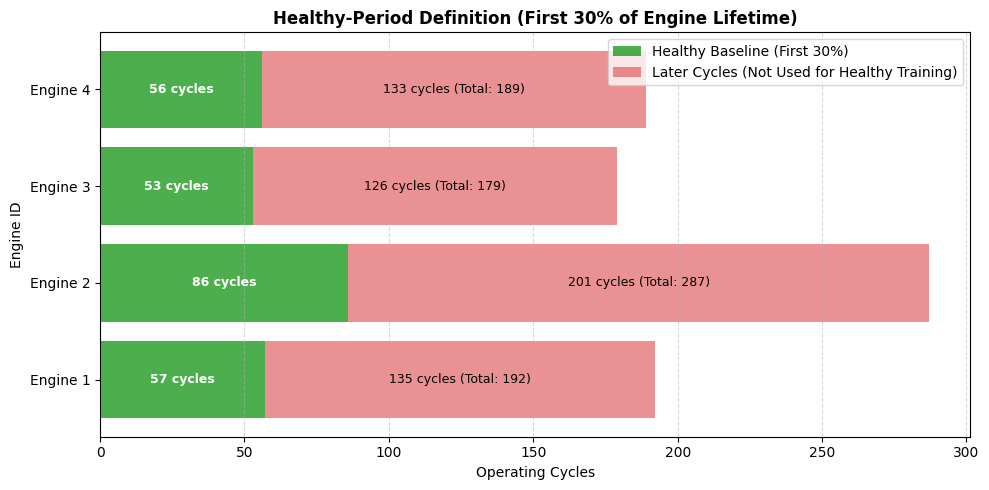

Saved figure to: C:\Users\mahta\AIdev\turbofan-failure-detection\reports\figures\mahtab\healthy_period_definition.png


In [10]:
# Calculate maximum cycle and healthy cutoff per training engine
engine_healthy_info = train_df.groupby('unit_number')['cycle'].max().reset_index()
engine_healthy_info.rename(columns={'cycle': 'max_cycle'}, inplace=True)
engine_healthy_info['healthy_cutoff'] = np.floor(engine_healthy_info['max_cycle'] * 0.30).astype(int)
engine_healthy_info['number_of_healthy_cycles'] = engine_healthy_info['healthy_cutoff']

print("=== Healthy Period Summary Table (First 10 Engines) ===")
display(engine_healthy_info.head(10))

# Merge healthy cutoff back to training DataFrame
train_df_with_cutoff = train_df.merge(engine_healthy_info[['unit_number', 'healthy_cutoff']], on='unit_number')
train_df_with_cutoff['is_healthy'] = train_df_with_cutoff['cycle'] <= train_df_with_cutoff['healthy_cutoff']

# Filter healthy training dataset
healthy_train_all = train_df_with_cutoff[train_df_with_cutoff['is_healthy']].copy()

# Summary statistics
min_healthy_cutoff = engine_healthy_info['healthy_cutoff'].min()
max_healthy_cutoff = engine_healthy_info['healthy_cutoff'].max()
mean_healthy_cutoff = engine_healthy_info['healthy_cutoff'].mean()
median_healthy_cutoff = engine_healthy_info['healthy_cutoff'].median()
total_healthy_rows = len(healthy_train_all)

print("\n=== Healthy Period Statistics ===")
print(f"Minimum Healthy Cutoff : {min_healthy_cutoff} cycles")
print(f"Maximum Healthy Cutoff : {max_healthy_cutoff} cycles")
print(f"Mean Healthy Cutoff    : {mean_healthy_cutoff:.2f} cycles")
print(f"Median Healthy Cutoff  : {median_healthy_cutoff:.1f} cycles")
print(f"Total Healthy Rows     : {total_healthy_rows}")

# Assertions
assert (engine_healthy_info['healthy_cutoff'] > 0).all(), "Some engines have no healthy cutoff!"
assert total_healthy_rows == engine_healthy_info['healthy_cutoff'].sum(), "Healthy row count mismatch!"

# Create visualization of healthy period definition for example engines
example_units = [1, 2, 3, 4]
fig, ax = plt.subplots(figsize=(10, 5))

for i, unit in enumerate(example_units):
    unit_info = engine_healthy_info[engine_healthy_info['unit_number'] == unit].iloc[0]
    max_c = unit_info['max_cycle']
    cutoff = unit_info['healthy_cutoff']
    
    # Timeline bars
    ax.barh(y=f"Engine {unit}", width=cutoff, color='#2ca02c', alpha=0.85, label='Healthy Baseline (First 30%)' if i==0 else "")
    ax.barh(y=f"Engine {unit}", width=max_c - cutoff, left=cutoff, color='#d62728', alpha=0.5, label='Later Cycles (Not Used for Healthy Training)' if i==0 else "")
    
    # Text labels
    ax.text(cutoff / 2, i, f"{cutoff} cycles", ha='center', va='center', color='white', fontweight='bold', fontsize=9)
    ax.text(cutoff + (max_c - cutoff) / 2, i, f"{max_c - cutoff} cycles (Total: {max_c})", ha='center', va='center', color='black', fontsize=9)

ax.set_title('Healthy-Period Definition (First 30% of Engine Lifetime)', fontsize=12, fontweight='bold')
ax.set_xlabel('Operating Cycles', fontsize=10)
ax.set_ylabel('Engine ID', fontsize=10)
ax.legend(loc='upper right')
ax.grid(True, axis='x', linestyle='--', alpha=0.5)
plt.tight_layout()

healthy_fig_path = figures_dir / 'healthy_period_definition.png'
plt.savefig(healthy_fig_path, dpi=300)
plt.show()

print(f"Saved figure to: {healthy_fig_path}")


## STEP 11 — Engine-Level Train / Validation Split

We perform an **engine-level split** using `random_state = 42`:
- **80 Training Engines**
- **20 Validation Engines**

*Critical Design Decision*: Splitting by engine unit number (rather than individual rows) avoids temporal data leakage between overlapping windows from the same engine lifetime.

Autoencoder training and validation sets utilize **only healthy rows** from their respective engine groups.


In [11]:
# Extract unique engine IDs
unique_engine_ids = train_df['unit_number'].unique()

# Perform engine-level split (80 / 20)
train_engine_ids, val_engine_ids = train_test_split(
    unique_engine_ids, test_size=0.20, random_state=42
)

# Sort engine IDs for clarity
train_engine_ids = np.sort(train_engine_ids)
val_engine_ids = np.sort(val_engine_ids)

print("=== STEP 11: ENGINE-LEVEL SPLIT ===")
print(f"Training Engine Count   : {len(train_engine_ids)}")
print(f"Validation Engine Count : {len(val_engine_ids)}")

# Verify split properties
assert len(train_engine_ids) == 80, f"Expected 80 train engines, got {len(train_engine_ids)}"
assert len(val_engine_ids) == 20, f"Expected 20 val engines, got {len(val_engine_ids)}"
assert len(set(train_engine_ids).intersection(set(val_engine_ids))) == 0, "Overlap found between train and validation engines!"
assert len(set(train_engine_ids).union(set(val_engine_ids))) == 100, "Engine count sum does not equal 100!"

# Filter healthy rows for training and validation engine groups
healthy_train_df = healthy_train_all[healthy_train_all['unit_number'].isin(train_engine_ids)].copy()
healthy_val_df = healthy_train_all[healthy_train_all['unit_number'].isin(val_engine_ids)].copy()

print(f"Healthy rows in Train engine group      : {len(healthy_train_df)}")
print(f"Healthy rows in Validation engine group : {len(healthy_val_df)}")
print(f"Total Healthy Rows                      : {len(healthy_train_df) + len(healthy_val_df)}")


=== STEP 11: ENGINE-LEVEL SPLIT ===
Training Engine Count   : 80
Validation Engine Count : 20
Healthy rows in Train engine group      : 4931
Healthy rows in Validation engine group : 1213
Total Healthy Rows                      : 6144


## STEP 12 — Feature Scaling Without Data Leakage

We use `sklearn.preprocessing.StandardScaler`:
- **Fit Rule**: The scaler is fitted **ONLY on the 14 selected sensor features of healthy rows from the 80 training engines** (`healthy_train_df`).
- **Strict Leakage Prevention**: Validation engines, degraded training cycles, test data, and RUL targets are never used during fitting.

We then use the fitted scaler to transform:
1. Healthy training-engine rows (`healthy_train_scaled_df`)
2. Healthy validation-engine rows (`healthy_val_scaled_df`)
3. Complete FD001 training sensor data (`train_full_scaled_df`)
4. Complete FD001 test sensor data (`test_full_scaled_df`)

Metadata columns (`unit_number`, `cycle`) are preserved alongside transformed features with exact index alignment.


In [12]:
# Initialize StandardScaler
scaler = StandardScaler()

# 1. Fit scaler ONLY on healthy rows of training engines using 14 selected sensors
scaler.fit(healthy_train_df[selected_sensors])

print("StandardScaler fitted on healthy training rows.")

# Function to transform sensor features while preserving metadata and index alignment
def transform_with_metadata(df, selected_sensors, metadata_cols):
    scaled_array = scaler.transform(df[selected_sensors])
    scaled_df = pd.DataFrame(
        scaled_array,
        columns=selected_sensors,
        index=df.index
    )
    for col in metadata_cols:
        if col in df.columns:
            scaled_df[col] = df[col]
    return scaled_df

# 2. Transform all required subsets
healthy_train_scaled_df = transform_with_metadata(healthy_train_df, selected_sensors, metadata_cols)
healthy_val_scaled_df = transform_with_metadata(healthy_val_df, selected_sensors, metadata_cols)
train_full_scaled_df = transform_with_metadata(train_df, selected_sensors, metadata_cols)
test_full_scaled_df = transform_with_metadata(test_df, selected_sensors, metadata_cols)

# 3. Verify metadata alignment and zero NaNs for all transformed subsets
subsets_to_check = [
    ("Healthy Train", healthy_train_df, healthy_train_scaled_df),
    ("Healthy Val", healthy_val_df, healthy_val_scaled_df),
    ("Full Train", train_df, train_full_scaled_df),
    ("Full Test", test_df, test_full_scaled_df)
]

print("\n=== STEP 12: METADATA ALIGNMENT VERIFICATION ===")
for name, orig_df, scaled_df in subsets_to_check:
    for col in metadata_cols:
        assert scaled_df[col].isnull().sum() == 0, f"{name}: {col} contains NaN values!"
        assert (scaled_df[col].values == orig_df[col].values).all(), f"{name}: {col} values/order mismatch!"
    print(f"Verified {name:15s}: metadata ('unit_number', 'cycle') matches original DataFrame 1:1 with 0 NaNs.")

print(f"\nTransformed healthy train shape : {healthy_train_scaled_df[selected_sensors].shape}")
print(f"Transformed healthy val shape   : {healthy_val_scaled_df[selected_sensors].shape}")
print(f"Transformed full train shape    : {train_full_scaled_df[selected_sensors].shape}")
print(f"Transformed full test shape     : {test_full_scaled_df[selected_sensors].shape}")


StandardScaler fitted on healthy training rows.

=== STEP 12: METADATA ALIGNMENT VERIFICATION ===
Verified Healthy Train  : metadata ('unit_number', 'cycle') matches original DataFrame 1:1 with 0 NaNs.
Verified Healthy Val    : metadata ('unit_number', 'cycle') matches original DataFrame 1:1 with 0 NaNs.
Verified Full Train     : metadata ('unit_number', 'cycle') matches original DataFrame 1:1 with 0 NaNs.
Verified Full Test      : metadata ('unit_number', 'cycle') matches original DataFrame 1:1 with 0 NaNs.

Transformed healthy train shape : (4931, 14)
Transformed healthy val shape   : (1213, 14)
Transformed full train shape    : (20631, 14)
Transformed full test shape     : (13096, 14)


## STEP 13 — Scaling Validation

We verify the post-scaling properties on the data used to fit the scaler (`healthy_train_scaled_df`):
- Feature means should be approximately **0.0**
- Feature standard deviations should be approximately **1.0** (calculated with `ddof=0` matching `StandardScaler`)
- Check for NaNs, Infs, and correct feature count (14)


In [13]:
# Extract scaled feature array used for fitting
scaled_fit_data = healthy_train_scaled_df[selected_sensors].values

scaled_means = scaled_fit_data.mean(axis=0)
# Population standard deviation matching StandardScaler (ddof=0)
scaled_stds = scaled_fit_data.std(axis=0, ddof=0)

scaling_check_df = pd.DataFrame({
    'sensor': selected_sensors,
    'post_scale_mean': scaled_means,
    'post_scale_std': scaled_stds
})

print("=== STEP 13: POST-SCALING MEAN & STD VERIFICATION (ddof=0) ===")
display(scaling_check_df)

# Assertions
assert np.allclose(scaled_means, 0, atol=1e-6), "Scaled means are not close to 0!"
assert np.allclose(scaled_stds, 1, atol=1e-6), "Scaled stds are not close to 1!"
assert not np.isnan(scaled_fit_data).any(), "NaN values found after scaling!"
assert not np.isinf(scaled_fit_data).any(), "Infinite values found after scaling!"
assert scaled_fit_data.shape[1] == 14, f"Expected 14 scaled features, got {scaled_fit_data.shape[1]}"

print("\nScaling validation assertions passed successfully.")


=== STEP 13: POST-SCALING MEAN & STD VERIFICATION (ddof=0) ===


,sensor,post_scale_mean,post_scale_std
0,sensor_2,-2.529134e-13,1.0
1,sensor_3,-5.453498e-14,1.0
2,sensor_4,-3.402997e-14,1.0
3,sensor_7,1.758763e-13,1.0
4,sensor_8,-1.389338e-12,1.0
5,sensor_9,-1.297450e-13,1.0
6,sensor_11,4.241065e-14,1.0
7,sensor_12,-9.331727e-15,1.0
8,sensor_13,-2.032239e-12,1.0
9,sensor_14,1.068855e-13,1.0



Scaling validation assertions passed successfully.


## STEP 14 — Preprocessing Findings Summary

Below is a concise summary of the preprocessing preparation steps completed for dataset **FD001**:

1. **Original vs. Selected Sensors**:
   - **21 original sensors** evaluated in raw data.
   - **7 low-information sensors excluded**: `sensor_1`, `sensor_5`, `sensor_6`, `sensor_10`, `sensor_16`, `sensor_18`, `sensor_19` (constant or nearly constant).
   - **14 selected sensors retained**: `sensor_2`, `sensor_3`, `sensor_4`, `sensor_7`, `sensor_8`, `sensor_9`, `sensor_11`, `sensor_12`, `sensor_13`, `sensor_14`, `sensor_15`, `sensor_17`, `sensor_20`, `sensor_21`.

2. **Healthy Period Definition**:
   - Defined as the **first 30% of each training engine's lifetime** ($\text{cycle} \le \lfloor \text{max\_cycle} \times 0.30 \rfloor$).
   - Yielded **6,144 total healthy training rows** across all 100 training engines.
   - Healthy cutoff per engine ranges from **38 to 108 cycles** (Mean: 61.44, Median: 59.0).

3. **Engine-Level Train / Validation Split**:
   - **80 training engines** and **20 validation engines** split by `unit_number` using `random_state = 42`.
   - **Healthy training group**: 4,931 healthy rows (across 80 engines).
   - **Healthy validation group**: 1,213 healthy rows (across 20 engines).

4. **Data-Leakage-Free Feature Scaling**:
   - `StandardScaler` fitted **exclusively on healthy rows belonging to the 80 training engines** (4,931 rows × 14 features).
   - Applied fitted scaler to transform healthy validation rows, complete training set (20,631 rows), and complete test set (13,096 rows).
   - Post-scaling verification confirmed means $= 0.0$ and stds $= 1.0$ on the fit set with 0 NaNs and 0 Infs.

5. **Model & Target Integrity**:
   - `RUL` and operational settings were **not used** for model feature scaling or training setup.
   - Raw DataFrames and metadata columns (`unit_number`, `cycle`) remain intact for future sequence windowing and timeline reconstruction.


## STEP 15 — Define Window Configuration

We define the sequence windowing configuration for the Autoencoder:
- **`window_size`**: `30` cycles
- **`stride`**: `1`
- **Features per cycle**: `14` selected scaled sensors
- **Individual window shape**: `(30, 14)`

The Autoencoder model will later be trained to reconstruct an entire 30-cycle multivariate sensor window.


In [14]:
# Shared project window settings
window_size = 30
stride = 1

print("=== STEP 15: WINDOW CONFIGURATION ===")
print(f"Window Size : {window_size} cycles")
print(f"Stride      : {stride}")
print(f"Features    : {len(selected_sensors)} selected scaled sensors")
print(f"Expected Individual Window Shape : ({window_size}, {len(selected_sensors)})")


=== STEP 15: WINDOW CONFIGURATION ===
Window Size : 30 cycles
Stride      : 1
Features    : 14 selected scaled sensors
Expected Individual Window Shape : (30, 14)


## STEP 16 — Create a Safe Window Function

We construct a robust, reusable function `create_windows()` that converts engine sensor DataFrames into 3D sequence arrays:
1. **Engine Isolation**: Windows are generated independently per `unit_number` and **NEVER cross engine boundaries**.
2. **Chronological Sorting**: Rows within each engine are sorted by `cycle` prior to window extraction.
3. **Consecutive Cycle Validation**: Checks that cycle numbers within every 30-cycle window are strictly consecutive ($\Delta \text{cycle} = 1$).
4. **Metadata Preservation**: Metadata DataFrame tracks `unit_number`, `start_cycle`, and `end_cycle` for every window.
5. **End-Cycle Assignment**: Each window is assigned to its `end_cycle` so that downstream reconstruction errors align directly with engine timelines and RUL evaluation.


In [15]:
def create_windows(df, feature_cols, window_size=30, stride=1):
    """
    Generates 3D sliding sequence windows (samples, window_size, features) 
    strictly within individual engine boundaries and tracks window metadata.
    """
    windows_list = []
    metadata_list = []
    
    # Process each engine independently
    for unit_id, group in df.groupby('unit_number'):
        # Ensure chronological sorting by cycle
        group_sorted = group.sort_values(by='cycle').reset_index(drop=True)
        cycles = group_sorted['cycle'].values
        features = group_sorted[feature_cols].values
        
        n_rows = len(group_sorted)
        if n_rows < window_size:
            print(f"Warning: Engine {unit_id} has {n_rows} cycles, which is less than window_size ({window_size}). Skipping.")
            continue
            
        for i in range(0, n_rows - window_size + 1, stride):
            win_features = features[i : i + window_size]
            win_cycles = cycles[i : i + window_size]
            
            # Validate consecutive cycles
            cycle_diffs = np.diff(win_cycles)
            if not np.all(cycle_diffs == 1):
                raise ValueError(f"Non-consecutive cycles detected in Engine {unit_id} window starting at cycle {win_cycles[0]}: {win_cycles}")
                
            start_cycle = int(win_cycles[0])
            end_cycle = int(win_cycles[-1])
            
            windows_list.append(win_features)
            metadata_list.append({
                'unit_number': int(unit_id),
                'start_cycle': start_cycle,
                'end_cycle': end_cycle
            })
            
    windows_arr = np.array(windows_list)
    metadata_df = pd.DataFrame(metadata_list)
    return windows_arr, metadata_df

print("Safe windowing function `create_windows()` defined successfully.")


Safe windowing function `create_windows()` defined successfully.


## STEP 17 — Healthy Training Windows

We generate training windows from `healthy_train_scaled_df` (containing only healthy cycles from the 80 training engines).

- **Expected Window Count Formula**:
  $$\text{Total Healthy Rows} - (\text{window\_size} - 1) \times \text{Number of Engines} = 4931 - 29 \times 80 = 2611 \text{ windows}$$
- **Expected Shape**: `(2611, 30, 14)`
- **Healthy Cutoff Property**: Every window's `end_cycle` is $\le$ that engine's `healthy_cutoff`.


In [16]:
# Create healthy training windows
X_train_windows, train_window_metadata = create_windows(
    healthy_train_scaled_df, feature_cols=selected_sensors, window_size=30, stride=1
)

print("=== STEP 17: HEALTHY TRAINING WINDOWS ===")
print(f"X_train_windows shape : {X_train_windows.shape}")
print(f"train_window_metadata shape : {train_window_metadata.shape}")

# Assertions
assert X_train_windows.shape == (2611, 30, 14), f"Expected shape (2611, 30, 14), got {X_train_windows.shape}"
assert len(train_window_metadata) == 2611, f"Expected 2611 metadata rows, got {len(train_window_metadata)}"
assert train_window_metadata['unit_number'].nunique() == 80, "Expected 80 unique training engines"
assert not np.isnan(X_train_windows).any(), "NaN values found in X_train_windows"
assert not np.isinf(X_train_windows).any(), "Infinite values found in X_train_windows"

# Verify end_cycle <= healthy_cutoff for all healthy training windows
train_meta_merged = train_window_metadata.merge(engine_healthy_info[['unit_number', 'healthy_cutoff']], on='unit_number')
assert (train_meta_merged['end_cycle'] <= train_meta_merged['healthy_cutoff']).all(), "Training window end_cycle exceeds healthy cutoff!"

print("\nHealthy training windows verified: 2,611 windows created across 80 engines, all within healthy cutoff.")


=== STEP 17: HEALTHY TRAINING WINDOWS ===
X_train_windows shape : (2611, 30, 14)
train_window_metadata shape : (2611, 3)

Healthy training windows verified: 2,611 windows created across 80 engines, all within healthy cutoff.


## STEP 18 — Healthy Validation Windows

We generate validation windows from `healthy_val_scaled_df` (containing healthy cycles from the 20 validation engines).

- **Expected Window Count Formula**:
  $$\text{Total Healthy Val Rows} - (\text{window\_size} - 1) \times \text{Number of Val Engines} = 1213 - 29 \times 20 = 633 \text{ windows}$$
- **Expected Shape**: `(633, 30, 14)`
- **Disjoint Check**: 0 overlapping engines with the training group.


In [17]:
# Create healthy validation windows
X_val_windows, val_window_metadata = create_windows(
    healthy_val_scaled_df, feature_cols=selected_sensors, window_size=30, stride=1
)

print("=== STEP 18: HEALTHY VALIDATION WINDOWS ===")
print(f"X_val_windows shape : {X_val_windows.shape}")
print(f"val_window_metadata shape : {val_window_metadata.shape}")

# Assertions
assert X_val_windows.shape == (633, 30, 14), f"Expected shape (633, 30, 14), got {X_val_windows.shape}"
assert len(val_window_metadata) == 633, f"Expected 633 metadata rows, got {len(val_window_metadata)}"
assert val_window_metadata['unit_number'].nunique() == 20, "Expected 20 unique validation engines"
assert len(set(train_window_metadata['unit_number']).intersection(set(val_window_metadata['unit_number']))) == 0, "Engine overlap detected!"
assert not np.isnan(X_val_windows).any(), "NaN values found in X_val_windows"
assert not np.isinf(X_val_windows).any(), "Infinite values found in X_val_windows"

# Verify end_cycle <= healthy_cutoff for all healthy validation windows
val_meta_merged = val_window_metadata.merge(engine_healthy_info[['unit_number', 'healthy_cutoff']], on='unit_number')
assert (val_meta_merged['end_cycle'] <= val_meta_merged['healthy_cutoff']).all(), "Validation window end_cycle exceeds healthy cutoff!"

print("\nHealthy validation windows verified: 633 windows created across 20 engines, all within healthy cutoff.")


=== STEP 18: HEALTHY VALIDATION WINDOWS ===
X_val_windows shape : (633, 30, 14)
val_window_metadata shape : (633, 3)

Healthy validation windows verified: 633 windows created across 20 engines, all within healthy cutoff.


## STEP 19 — Full Train Windows for Later Evaluation

We generate sequence windows across the **entire observed trajectories of all 100 training engines** (`train_full_scaled_df`).

*Purpose*: These windows are **NOT for model fitting**. They will be evaluated later to track how Autoencoder reconstruction error evolves from healthy operation through progressive HPC degradation until engine failure.

- **Expected Window Count**:
  $$20631 - 29 \times 100 = 17731 \text{ windows}$$
- **Expected Shape**: `(17731, 30, 14)`


In [18]:
# Create full training windows for evaluation
X_full_train_windows, full_train_window_metadata = create_windows(
    train_full_scaled_df, feature_cols=selected_sensors, window_size=30, stride=1
)

print("=== STEP 19: FULL TRAIN WINDOWS FOR EVALUATION ===")
print(f"X_full_train_windows shape : {X_full_train_windows.shape}")
print(f"full_train_window_metadata shape : {full_train_window_metadata.shape}")

# Assertions
assert X_full_train_windows.shape == (17731, 30, 14), f"Expected shape (17731, 30, 14), got {X_full_train_windows.shape}"
assert len(full_train_window_metadata) == 17731, f"Expected 17731 metadata rows, got {len(full_train_window_metadata)}"
assert full_train_window_metadata['unit_number'].nunique() == 100, "Expected 100 unique training engines"
assert not np.isnan(X_full_train_windows).any(), "NaN values found in X_full_train_windows"
assert not np.isinf(X_full_train_windows).any(), "Infinite values found in X_full_train_windows"

print("\nFull training evaluation windows verified: 17,731 windows created across all 100 training engines.")


=== STEP 19: FULL TRAIN WINDOWS FOR EVALUATION ===
X_full_train_windows shape : (17731, 30, 14)
full_train_window_metadata shape : (17731, 3)

Full training evaluation windows verified: 17,731 windows created across all 100 training engines.


## STEP 20 — Full Test Windows for Later Evaluation

We generate sequence windows across all observed cycles of test engines (`test_full_scaled_df`).

First, we verify that every test engine has at least 30 observed cycles before window extraction.
- Minimum test engine cycle count = `31` cycles ($\ge 30$).
- **Expected Window Count**:
  $$13096 - 29 \times 100 = 10196 \text{ windows}$$
- **Expected Shape**: `(10196, 30, 14)`


In [19]:
# Check minimum cycle count per test engine
min_test_cycles = test_df.groupby('unit_number')['cycle'].max().min()
print(f"Minimum observed cycles across test engines: {min_test_cycles}")
assert min_test_cycles >= 30, f"Some test engines have fewer than 30 cycles! Minimum found: {min_test_cycles}"

# Create full test windows for evaluation
X_test_windows, test_window_metadata = create_windows(
    test_full_scaled_df, feature_cols=selected_sensors, window_size=30, stride=1
)

print("=== STEP 20: FULL TEST WINDOWS FOR EVALUATION ===")
print(f"X_test_windows shape : {X_test_windows.shape}")
print(f"test_window_metadata shape : {test_window_metadata.shape}")

# Assertions
assert X_test_windows.shape == (10196, 30, 14), f"Expected shape (10196, 30, 14), got {X_test_windows.shape}"
assert len(test_window_metadata) == 10196, f"Expected 10196 metadata rows, got {len(test_window_metadata)}"
assert test_window_metadata['unit_number'].nunique() == 100, "Expected 100 unique test engines"
assert not np.isnan(X_test_windows).any(), "NaN values found in X_test_windows"
assert not np.isinf(X_test_windows).any(), "Infinite values found in X_test_windows"

print("\nFull test evaluation windows verified: 10,196 windows created across all 100 test engines.")


Minimum observed cycles across test engines: 31
=== STEP 20: FULL TEST WINDOWS FOR EVALUATION ===
X_test_windows shape : (10196, 30, 14)
test_window_metadata shape : (10196, 3)

Full test evaluation windows verified: 10,196 windows created across all 100 test engines.


## STEP 21 — Window Integrity Checks

We run comprehensive integrity checks across all four window arrays and metadata DataFrames:


In [20]:
print("=== STEP 21: COMPREHENSIVE WINDOW INTEGRITY CHECKS ===")

# 1. Shapes
assert X_train_windows.shape == (2611, 30, 14), "X_train_windows shape error"
assert X_val_windows.shape == (633, 30, 14), "X_val_windows shape error"
assert X_full_train_windows.shape == (17731, 30, 14), "X_full_train_windows shape error"
assert X_test_windows.shape == (10196, 30, 14), "X_test_windows shape error"
print("1. All 4 window array shapes verified.")

# 2. Metadata length equality
assert len(X_train_windows) == len(train_window_metadata), "Train metadata count mismatch"
assert len(X_val_windows) == len(val_window_metadata), "Val metadata count mismatch"
assert len(X_full_train_windows) == len(full_train_window_metadata), "Full train metadata count mismatch"
assert len(X_test_windows) == len(test_window_metadata), "Test metadata count mismatch"
print("2. Window array lengths match metadata DataFrame row counts 1:1.")

# 3. Window cycle span property (end_cycle - start_cycle + 1 == 30)
for name, meta in [("Train", train_window_metadata), ("Val", val_window_metadata), 
                   ("Full Train", full_train_window_metadata), ("Test", test_window_metadata)]:
    spans = meta['end_cycle'] - meta['start_cycle'] + 1
    assert (spans == 30).all(), f"{name}: Window cycle span error!"
print("3. Every window spans exactly 30 consecutive cycles (end_cycle - start_cycle + 1 == 30).")

# 4. Engine isolation & Engine count representation
assert train_window_metadata['unit_number'].nunique() == 80, "Train engine count error"
assert val_window_metadata['unit_number'].nunique() == 20, "Val engine count error"
assert full_train_window_metadata['unit_number'].nunique() == 100, "Full train engine count error"
assert test_window_metadata['unit_number'].nunique() == 100, "Test engine count error"
print("4. Engine counts verified: Train=80, Val=20, Full Train=100, Test=100.")

# 5. Disjoint Train vs Val Engine IDs
assert len(set(train_window_metadata['unit_number']).intersection(set(val_window_metadata['unit_number']))) == 0, "Train/Val overlap error"
print("5. Training and validation engine IDs are 100% disjoint.")

# 6. Healthy Cutoff Bound Verification
assert (train_meta_merged['end_cycle'] <= train_meta_merged['healthy_cutoff']).all(), "Train healthy window cutoff error"
assert (val_meta_merged['end_cycle'] <= val_meta_merged['healthy_cutoff']).all(), "Val healthy window cutoff error"
print("6. All healthy train and validation windows end strictly within their engine's 30% healthy cutoff.")

# 7. Data Quality (No NaNs or Infs)
for arr_name, arr in [("X_train_windows", X_train_windows), ("X_val_windows", X_val_windows),
                      ("X_full_train_windows", X_full_train_windows), ("X_test_windows", X_test_windows)]:
    assert not np.isnan(arr).any(), f"{arr_name} contains NaN!"
    assert not np.isinf(arr).any(), f"{arr_name} contains Inf!"
print("7. Zero NaN and zero Infinite values across all 4 window arrays.")

print("\nAll 11 Window Integrity Checks Passed Successfully!")


=== STEP 21: COMPREHENSIVE WINDOW INTEGRITY CHECKS ===
1. All 4 window array shapes verified.
2. Window array lengths match metadata DataFrame row counts 1:1.
3. Every window spans exactly 30 consecutive cycles (end_cycle - start_cycle + 1 == 30).
4. Engine counts verified: Train=80, Val=20, Full Train=100, Test=100.
5. Training and validation engine IDs are 100% disjoint.
6. All healthy train and validation windows end strictly within their engine's 30% healthy cutoff.
7. Zero NaN and zero Infinite values across all 4 window arrays.

All 11 Window Integrity Checks Passed Successfully!


## STEP 22 — Visual Window Example

We generate an educational diagram illustrating how sliding windows with `window_size = 30` and `stride = 1` are extracted for an example training engine (Engine 1).

Each window moves forward by 1 cycle, and its assigned `end_cycle` marks the point at which reconstruction error will later be evaluated.


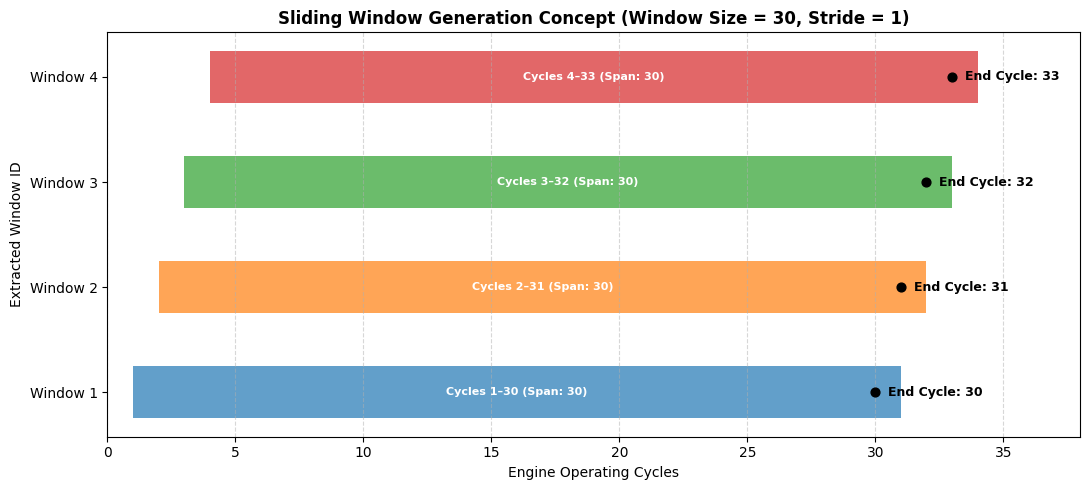

Saved figure to: C:\Users\mahta\AIdev\turbofan-failure-detection\reports\figures\mahtab\windowing_example.png


In [21]:
# Create visual illustration of sliding window generation for Engine 1
fig, ax = plt.subplots(figsize=(11, 5))

window_examples = [
    (1, 30, 'Window 1 (Cycles 1–30)', '#1f77b4'),
    (2, 31, 'Window 2 (Cycles 2–31)', '#ff7f0e'),
    (3, 32, 'Window 3 (Cycles 3–32)', '#2ca02c'),
    (4, 33, 'Window 4 (Cycles 4–33)', '#d62728')
]

for idx, (start, end, label, color) in enumerate(window_examples):
    # Horizontal window bar
    ax.barh(y=f"Window {idx+1}", width=30, left=start, color=color, alpha=0.7, height=0.5)
    # End cycle marker dot
    ax.scatter(end, idx, color='black', zorder=5, s=40)
    ax.text(end + 0.5, idx, f"End Cycle: {end}", va='center', fontsize=9, fontweight='bold')
    ax.text(start + 15, idx, f"Cycles {start}–{end} (Span: 30)", ha='center', va='center', color='white', fontweight='bold', fontsize=8)

ax.set_title('Sliding Window Generation Concept (Window Size = 30, Stride = 1)', fontsize=12, fontweight='bold')
ax.set_xlabel('Engine Operating Cycles', fontsize=10)
ax.set_ylabel('Extracted Window ID', fontsize=10)
ax.set_xlim(0, 38)
ax.grid(True, axis='x', linestyle='--', alpha=0.5)
plt.tight_layout()

window_fig_path = figures_dir / 'windowing_example.png'
plt.savefig(window_fig_path, dpi=300)
plt.show()

print(f"Saved figure to: {window_fig_path}")


## STEP 23 — Windowing Findings Summary

Below is a concise summary of the sequence windowing implementation for dataset **FD001**:

1. **Window Configuration**:
   - **`window_size`**: `30` cycles
   - **`stride`**: `1`
   - **Features per cycle**: `14` selected scaled sensors
   - **Individual Window Shape**: `(30, 14)` (unflattened for flexible Autoencoder architecture design)

2. **Per-Engine Isolation**:
   - Windows are generated independently for each engine and **never cross engine boundaries**.
   - Chronological order by `cycle` is strictly enforced.
   - Each window's metadata tracks `unit_number`, `start_cycle`, and `end_cycle`.

3. **Window Array Dimensions**:
   - **`X_train_windows`**: `(2611, 30, 14)` — extracted from 4,931 healthy training rows across 80 training engines.
   - **`X_val_windows`**: `(633, 30, 14)` — extracted from 1,213 healthy validation rows across 20 validation engines.
   - **`X_full_train_windows`**: `(17731, 30, 14)` — extracted across complete trajectories of all 100 training engines (for downstream degradation evaluation).
   - **`X_test_windows`**: `(10196, 30, 14)` — extracted across all 100 test engines (minimum observed cycles per test engine = `31` $\ge 30$).

4. **Healthy Boundary Adherence**:
   - Every healthy training and validation window satisfies $\text{end\_cycle} \le \text{healthy\_cutoff}$, guaranteeing complete containment within the first 30% healthy baseline.

5. **Target & Model Integrity**:
   - `RUL` has **not** been used for model training or window creation.
   - Model building, neural network training, reconstruction error calculation, and anomaly thresholding have not been performed yet.


## STEP 24 — Reproducibility

We set fixed random seeds (`random_seed = 42`) across Python's `random` module, NumPy `np.random`, and Keras/TensorFlow to ensure fully reproducible model weight initialization and dataset shuffling.


In [22]:
# Set reproducible random seeds
random_seed = 42
random.seed(random_seed)
np.random.seed(random_seed)
keras.utils.set_random_seed(random_seed)

print(f"Reproducibility seeds set to: {random_seed}")


Reproducibility seeds set to: 42


## STEP 25 — Prepare Dense Autoencoder Input

For our first baseline fully-connected Dense Autoencoder, we flatten each 30-cycle $\times$ 14-sensor window into a single 1D vector of **420 features** ($30 \times 14 = 420$).

- **`X_train_ae`**: Shape `(2611, 420)`
- **`X_val_ae`**: Shape `(633, 420)`

*Note*: The original 3D window arrays (`X_train_windows` and `X_val_windows`) and metadata DataFrames remain intact and unflattened.


In [23]:
# Flatten 3D windows into 2D matrices for Dense Autoencoder
X_train_ae = X_train_windows.reshape(len(X_train_windows), -1)
X_val_ae = X_val_windows.reshape(len(X_val_windows), -1)

print("=== STEP 25: DENSE AUTOENCODER INPUT SHAPES ===")
print(f"X_train_ae shape : {X_train_ae.shape}")
print(f"X_val_ae shape   : {X_val_ae.shape}")

# Validation assertions
assert X_train_ae.shape == (2611, 420), f"Expected (2611, 420), got {X_train_ae.shape}"
assert X_val_ae.shape == (633, 420), f"Expected (633, 420), got {X_val_ae.shape}"
assert not np.isnan(X_train_ae).any(), "NaN values found in X_train_ae"
assert not np.isnan(X_val_ae).any(), "NaN values found in X_val_ae"
assert not np.isinf(X_train_ae).any(), "Infinite values found in X_train_ae"
assert not np.isinf(X_val_ae).any(), "Infinite values found in X_val_ae"

print("Dense input shapes and data quality verified: 420 input features per sample, 0 NaNs, 0 Infs.")


=== STEP 25: DENSE AUTOENCODER INPUT SHAPES ===
X_train_ae shape : (2611, 420)
X_val_ae shape   : (633, 420)
Dense input shapes and data quality verified: 420 input features per sample, 0 NaNs, 0 Infs.


## STEP 26 — Build Baseline Autoencoder Architecture

We construct a symmetric fully-connected Dense Autoencoder architecture:

- **Input Layer**: `Input(shape=(420,))`
- **Encoder**:
  - `Dense(128, activation='relu')`
  - `Dense(64, activation='relu')`
- **Latent Bottleneck**: `Dense(32, activation='relu', name='latent_space')`
- **Decoder**:
  - `Dense(64, activation='relu')`
  - `Dense(128, activation='relu')`
- **Output Layer**: `Dense(420, activation='linear', name='output_layer')`

*Loss Function Rationale*: We compile using **Mean Squared Error (MSE)** loss (`loss='mse'`) and Adam optimizer (`learning_rate=0.001`). MSE measures the squared error between original and reconstructed sensor window values.
*Output Layer Rationale*: The output activation is **`linear`** because standardized sensor features contain both positive and negative values.


In [24]:
# Build symmetric Dense Autoencoder model
baseline_dense_autoencoder = Sequential([
    Input(shape=(420,)),
    Dense(128, activation='relu', name='encoder_dense_1'),
    Dense(64, activation='relu', name='encoder_dense_2'),
    Dense(32, activation='relu', name='latent_space'),
    Dense(64, activation='relu', name='decoder_dense_1'),
    Dense(128, activation='relu', name='decoder_dense_2'),
    Dense(420, activation='linear', name='output_layer')
], name='baseline_dense_autoencoder')

# Compile model
baseline_dense_autoencoder.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='mse'
)

# Display model summary
print("=== STEP 26: BASELINE AUTOENCODER SUMMARY ===")
baseline_dense_autoencoder.summary()

# Report dimensions & parameter count
input_dim = 420
latent_dim = baseline_dense_autoencoder.get_layer('latent_space').units
output_dim = baseline_dense_autoencoder.get_layer('output_layer').units
trainable_params = baseline_dense_autoencoder.count_params()

print(f"\nInput Dimension         : {input_dim}")
print(f"Latent Bottleneck Dim   : {latent_dim}")
print(f"Output Dimension        : {output_dim}")
print(f"Total Trainable Params  : {trainable_params:,}")


=== STEP 26: BASELINE AUTOENCODER SUMMARY ===


Model: "baseline_dense_autoencoder"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ encoder_dense_1 (Dense)         │ (None, 128)            │        53,888 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ encoder_dense_2 (Dense)         │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ latent_space (Dense)            │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ decoder_dense_1 (Dense)         │ (None, 64)             │         2,112 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ decoder_dense_2 (Dense)         │ (None, 128)            │         8,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output_layer (Dense)            │ (None, 420)            │        54,180 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 128,836 (503.27 KB)

 Trainable params: 128,836 (503.27 KB)

 Non-trainable params: 0 (0.00 B)


Input Dimension         : 420
Latent Bottleneck Dim   : 32
Output Dimension        : 420
Total Trainable Params  : 128,836


## STEP 27 — Train Only on Healthy Windows

We train the model unsupervised to reconstruct healthy baseline behavior:
- **Training Input & Target**: `X_train_ae` $\to$ `X_train_ae` (2,611 healthy training windows)
- **Validation Data**: `(X_val_ae, X_val_ae)` (633 healthy validation windows from 20 separate engines)
- **Training Parameters**: `epochs = 100`, `batch_size = 32`, `shuffle = True`
- **EarlyStopping**: `monitor = 'val_loss'`, `patience = 10`, `restore_best_weights = True`

*Strict Isolation*: Full degradation trajectories, test engine trajectories, and RUL targets are **never** passed to `fit()`.


In [25]:
# Configure EarlyStopping callback
early_stopping = EarlyStopping(
    monitor='val_loss',
    patience=10,
    restore_best_weights=True,
    verbose=1
)

# Train Autoencoder
history = baseline_dense_autoencoder.fit(
    X_train_ae,
    X_train_ae,
    epochs=100,
    batch_size=32,
    shuffle=True,
    validation_data=(X_val_ae, X_val_ae),
    callbacks=[early_stopping],
    verbose=1
)

actual_epochs = len(history.history['loss'])
print(f"\nTraining completed! Total actual epochs executed: {actual_epochs}")


Epoch 1/100


 1/82 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - loss: 0.9250

 7/82 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.9649 

13/82 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.9509

20/82 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.9202

...

79/82 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.4317

82/82 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - loss: 0.4316 - val_loss: 0.4724


Epoch 29: early stopping


Restoring model weights from the end of the best epoch: 19.



Training completed! Total actual epochs executed: 29


## STEP 28 — Inspect Training & Validation Loss History

We inspect the training and validation loss curves over executed epochs to evaluate convergence and confirm absence of severe overfitting.


=== STEP 28: LOSS HISTORY STATISTICS ===
First Training Loss      : 0.591147
Final Training Loss      : 0.431621
Best Training Loss       : 0.431621
First Validation Loss    : 0.488853
Final Validation Loss    : 0.472368
Best Validation Loss     : 0.470750 (Epoch 19)


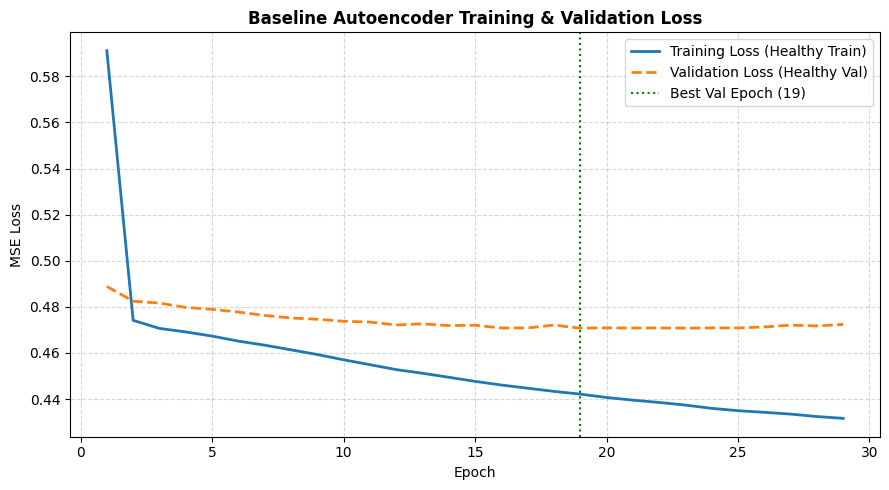

Saved figure to: C:\Users\mahta\AIdev\turbofan-failure-detection\reports\figures\mahtab\autoencoder_training_loss.png


In [26]:
train_loss = history.history['loss']
val_loss = history.history['val_loss']
epochs_range = range(1, actual_epochs + 1)

best_val_epoch = np.argmin(val_loss) + 1
best_val_loss = np.min(val_loss)

print("=== STEP 28: LOSS HISTORY STATISTICS ===")
print(f"First Training Loss      : {train_loss[0]:.6f}")
print(f"Final Training Loss      : {train_loss[-1]:.6f}")
print(f"Best Training Loss       : {np.min(train_loss):.6f}")
print(f"First Validation Loss    : {val_loss[0]:.6f}")
print(f"Final Validation Loss    : {val_loss[-1]:.6f}")
print(f"Best Validation Loss     : {best_val_loss:.6f} (Epoch {best_val_epoch})")

# Plot training & validation loss curves
plt.figure(figsize=(9, 5))
plt.plot(epochs_range, train_loss, label='Training Loss (Healthy Train)', color='#1f77b4', linewidth=2)
plt.plot(epochs_range, val_loss, label='Validation Loss (Healthy Val)', color='#ff7f0e', linewidth=2, linestyle='--')
plt.axvline(best_val_epoch, color='green', linestyle=':', label=f'Best Val Epoch ({best_val_epoch})')

plt.title('Baseline Autoencoder Training & Validation Loss', fontsize=12, fontweight='bold')
plt.xlabel('Epoch', fontsize=10)
plt.ylabel('MSE Loss', fontsize=10)
plt.legend(loc='upper right')
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()

# Save figure
loss_fig_path = figures_dir / 'autoencoder_training_loss.png'
plt.savefig(loss_fig_path, dpi=300)
plt.show()

print(f"Saved figure to: {loss_fig_path}")


## STEP 29 — Basic Healthy Reconstruction Check

We calculate the **Mean Squared Error (MSE) reconstruction error per window** across all 420 feature values:
$$\text{MSE}_{i} = \frac{1}{420} \sum_{j=1}^{420} (x_{i, j} - \hat{x}_{i, j})^2$$

We compute descriptive statistics (mean, median, std, min, max) for:
1. `train_reconstruction_error` (2,611 healthy training windows)
2. `val_reconstruction_error` (633 healthy validation windows)


In [27]:
# Generate model predictions for healthy train and validation inputs
X_train_pred = baseline_dense_autoencoder.predict(X_train_ae)
X_val_pred = baseline_dense_autoencoder.predict(X_val_ae)

# Calculate MSE per window across 420 feature values
train_reconstruction_error = np.mean((X_train_ae - X_train_pred) ** 2, axis=1)
val_reconstruction_error = np.mean((X_val_ae - X_val_pred) ** 2, axis=1)

# Summary statistics helper
def get_stats_dict(name, arr):
    return {
        'Dataset': name,
        'Count': len(arr),
        'Mean': np.mean(arr),
        'Median': np.median(arr),
        'Std': np.std(arr),
        'Min': np.min(arr),
        'Max': np.max(arr)
    }

rec_error_df = pd.DataFrame([
    get_stats_dict('Healthy Train (80 Engines)', train_reconstruction_error),
    get_stats_dict('Healthy Val (20 Engines)', val_reconstruction_error)
])

print("=== STEP 29: HEALTHY RECONSTRUCTION ERROR STATISTICS ===")
display(rec_error_df)


 1/82 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step

12/82 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step

22/82 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step

35/82 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step

48/82 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step

...

 1/20 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step

10/20 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step

20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step


=== STEP 29: HEALTHY RECONSTRUCTION ERROR STATISTICS ===


,Dataset,Count,Mean,Median,Std,Min,Max
0,Healthy Train (80 Engines),2611,0.43841,0.437854,0.032572,0.180079,0.546379
1,Healthy Val (20 Engines),633,0.47075,0.469482,0.030269,0.389653,0.561305


## STEP 30 — Healthy Reconstruction Error Distribution

We visualize the distribution of healthy training reconstruction error vs. healthy validation reconstruction error.

*Observation*: The error distributions of unseen healthy validation engines closely overlap with healthy training engines, confirming that the baseline Autoencoder generalizes well to unseen healthy baseline data.


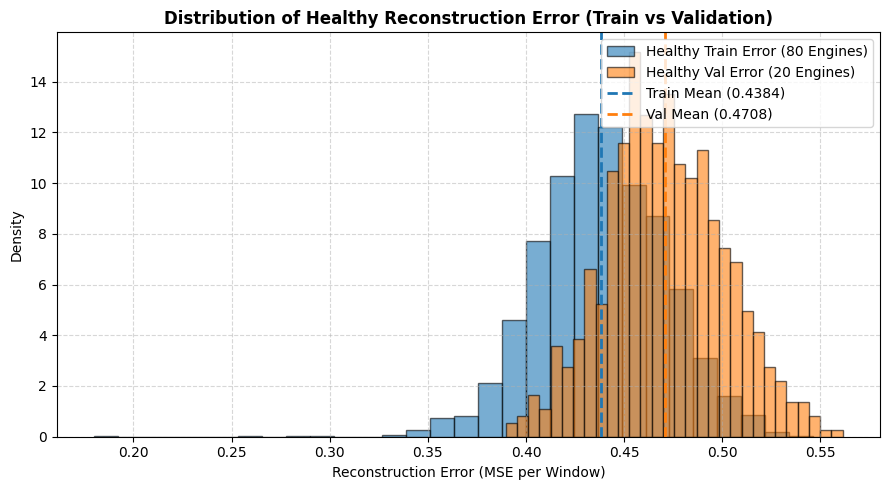

Saved figure to: C:\Users\mahta\AIdev\turbofan-failure-detection\reports\figures\mahtab\healthy_reconstruction_error.png


In [28]:
plt.figure(figsize=(9, 5))
plt.hist(train_reconstruction_error, bins=30, alpha=0.6, color='#1f77b4', edgecolor='black', density=True, label='Healthy Train Error (80 Engines)')
plt.hist(val_reconstruction_error, bins=30, alpha=0.6, color='#ff7f0e', edgecolor='black', density=True, label='Healthy Val Error (20 Engines)')

plt.axvline(np.mean(train_reconstruction_error), color='#1f77b4', linestyle='--', linewidth=2, label=f'Train Mean ({np.mean(train_reconstruction_error):.4f})')
plt.axvline(np.mean(val_reconstruction_error), color='#ff7f0e', linestyle='--', linewidth=2, label=f'Val Mean ({np.mean(val_reconstruction_error):.4f})')

plt.title('Distribution of Healthy Reconstruction Error (Train vs Validation)', fontsize=12, fontweight='bold')
plt.xlabel('Reconstruction Error (MSE per Window)', fontsize=10)
plt.ylabel('Density', fontsize=10)
plt.legend(loc='upper right')
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()

error_fig_path = figures_dir / 'healthy_reconstruction_error.png'
plt.savefig(error_fig_path, dpi=300)
plt.show()

print(f"Saved figure to: {error_fig_path}")


## Baseline Autoencoder Findings

Below is a concise summary of the baseline Autoencoder model training and healthy reconstruction results:

1. **Input Representation & Architecture**:
   - **Input Dimension**: `420` features ($30 \text{ cycles} \times 14 \text{ sensors}$).
   - **Original 3D Windows**: Preserved separately as `(2611, 30, 14)` and `(633, 30, 14)`.
   - **Symmetric Architecture**: `420` $\to$ `128` $\to$ `64` $\to$ `32` (Latent Bottleneck) $\to$ `64` $\to$ `128` $\to$ `420` (`linear` output).
   - **Total Trainable Parameters**: `128,836` parameters.

2. **Training & Convergence**:
   - **Training Set**: 2,611 healthy training windows (from 80 training engines).
   - **Validation Set**: 633 healthy validation windows (from 20 separate engines).
   - **Loss Function**: Mean Squared Error (MSE).
   - **EarlyStopping Configuration**: `monitor='val_loss'`, `patience=10`, `restore_best_weights=True`.
   - **Actual Epochs Executed**: `29` epochs.
   - **Best Validation Loss**: `0.470750` at Epoch `19`.

3. **Healthy Reconstruction Error**:
   - **Healthy Train Reconstruction Error**: Mean = `0.4384`, Median = `0.4379`, Std = `0.0326` (Min: `0.1801`, Max: `0.5464`).
   - **Healthy Validation Reconstruction Error**: Mean = `0.4707`, Median = `0.4695`, Std = `0.0303` (Min: `0.3897`, Max: `0.5613`).

4. **Strict Isolation Statement**:
   - *No test-engine data, full degradation trajectories, anomaly threshold, or RUL information was used during model training.*


## STEP 32 — Define Healthy Anomaly Threshold

We define the baseline anomaly threshold as the **95th percentile of healthy validation reconstruction error** (`val_reconstruction_error`):

```python
anomaly_threshold = np.percentile(val_reconstruction_error, 95)
```

*Strict Design Rule*: This threshold is derived exclusively from unseen healthy validation engines **BEFORE** scoring full trajectories, evaluating degradation trends, or accessing RUL targets. By construction, approximately 5% of healthy validation windows will lie above this threshold.


=== STEP 32: HEALTHY ANOMALY THRESHOLD SUMMARY ===
Anomaly Threshold (95th Percentile Val Error) : 0.521620
Healthy Validation Error Mean                 : 0.470750
Healthy Validation Error Median               : 0.469482
Percentage of Healthy Val Windows > Threshold : 5.06% (32 / 633)


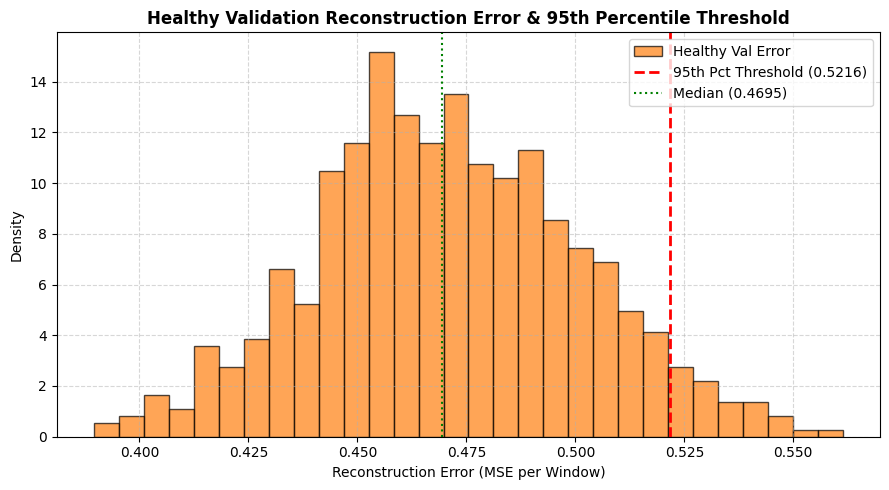

Saved figure to: C:\Users\mahta\AIdev\turbofan-failure-detection\reports\figures\mahtab\anomaly_threshold.png


In [29]:
# Define anomaly threshold at 95th percentile of healthy validation errors
anomaly_threshold = np.percentile(val_reconstruction_error, 95)

val_mean = np.mean(val_reconstruction_error)
val_median = np.median(val_reconstruction_error)
pct_val_above = np.mean(val_reconstruction_error > anomaly_threshold) * 100

print("=== STEP 32: HEALTHY ANOMALY THRESHOLD SUMMARY ===")
print(f"Anomaly Threshold (95th Percentile Val Error) : {anomaly_threshold:.6f}")
print(f"Healthy Validation Error Mean                 : {val_mean:.6f}")
print(f"Healthy Validation Error Median               : {val_median:.6f}")
print(f"Percentage of Healthy Val Windows > Threshold : {pct_val_above:.2f}% ({np.sum(val_reconstruction_error > anomaly_threshold)} / {len(val_reconstruction_error)})")

# Plot distribution and fixed threshold line
plt.figure(figsize=(9, 5))
plt.hist(val_reconstruction_error, bins=30, color='#ff7f0e', edgecolor='black', alpha=0.7, density=True, label='Healthy Val Error')
plt.axvline(anomaly_threshold, color='red', linestyle='--', linewidth=2, label=f'95th Pct Threshold ({anomaly_threshold:.4f})')
plt.axvline(val_median, color='green', linestyle=':', linewidth=1.5, label=f'Median ({val_median:.4f})')

plt.title('Healthy Validation Reconstruction Error & 95th Percentile Threshold', fontsize=12, fontweight='bold')
plt.xlabel('Reconstruction Error (MSE per Window)', fontsize=10)
plt.ylabel('Density', fontsize=10)
plt.legend(loc='upper right')
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()

threshold_fig_path = figures_dir / 'anomaly_threshold.png'
plt.savefig(threshold_fig_path, dpi=300)
plt.show()

print(f"Saved figure to: {threshold_fig_path}")


## STEP 33 — Prepare Full Trajectory Inputs

We flatten the 3D full train evaluation windows (`X_full_train_windows`) and test evaluation windows (`X_test_windows`) into 2D matrices for Dense Autoencoder scoring:

- **`X_full_train_ae`**: Shape `(17731, 420)`
- **`X_test_ae`**: Shape `(10196, 420)`

*Note*: The original 3D window arrays remain completely intact.


In [30]:
# Flatten 3D full evaluation arrays to 2D matrices
X_full_train_ae = X_full_train_windows.reshape(len(X_full_train_windows), -1)
X_test_ae = X_test_windows.reshape(len(X_test_windows), -1)

print("=== STEP 33: FULL TRAJECTORY INPUT SHAPES ===")
print(f"X_full_train_ae shape : {X_full_train_ae.shape}")
print(f"X_test_ae shape       : {X_test_ae.shape}")

# Verification assertions
assert X_full_train_ae.shape == (17731, 420), f"Expected (17731, 420), got {X_full_train_ae.shape}"
assert X_test_ae.shape == (10196, 420), f"Expected (10196, 420), got {X_test_ae.shape}"
assert not np.isnan(X_full_train_ae).any(), "NaN values found in X_full_train_ae!"
assert not np.isnan(X_test_ae).any(), "NaN values found in X_test_ae!"
assert not np.isinf(X_full_train_ae).any(), "Infinite values found in X_full_train_ae!"
assert not np.isinf(X_test_ae).any(), "Infinite values found in X_test_ae!"

print("Full trajectory input shapes and data quality verified: 0 NaNs, 0 Infs.")


=== STEP 33: FULL TRAJECTORY INPUT SHAPES ===
X_full_train_ae shape : (17731, 420)
X_test_ae shape       : (10196, 420)
Full trajectory input shapes and data quality verified: 0 NaNs, 0 Infs.


## STEP 34 — Score Full Train Trajectories

Using the trained baseline Autoencoder (without retraining), we generate reconstructions for `X_full_train_ae` and calculate MSE reconstruction error per window across all 420 feature values.

We construct `full_train_score_df` combining metadata (`unit_number`, `start_cycle`, `end_cycle`), `reconstruction_error`, and binary indicator `above_threshold` (`reconstruction_error > anomaly_threshold`).


In [31]:
# Predict reconstructions for full train trajectories
full_train_pred = baseline_dense_autoencoder.predict(X_full_train_ae, verbose=0)
full_train_reconstruction_error = np.mean((X_full_train_ae - full_train_pred) ** 2, axis=1)

# Attach results to metadata
full_train_score_df = full_train_window_metadata.copy()
full_train_score_df['reconstruction_error'] = full_train_reconstruction_error
full_train_score_df['above_threshold'] = full_train_score_df['reconstruction_error'] > anomaly_threshold

print("=== STEP 34: FULL TRAIN SCORING SUMMARY ===")
display(full_train_score_df.head())

n_full_train_above = full_train_score_df['above_threshold'].sum()
pct_full_train_above = (n_full_train_above / len(full_train_score_df)) * 100

print(f"Total Full Train Windows           : {len(full_train_score_df)}")
print(f"Full Train Windows > Threshold     : {n_full_train_above} ({pct_full_train_above:.2f}%)")
print(f"Full Train Reconstruction Mean     : {full_train_score_df['reconstruction_error'].mean():.6f}")
print(f"Full Train Reconstruction Median   : {full_train_score_df['reconstruction_error'].median():.6f}")


=== STEP 34: FULL TRAIN SCORING SUMMARY ===


,unit_number,start_cycle,end_cycle,reconstruction_error,above_threshold
0,1,1,30,0.475350,False
1,1,2,31,0.464542,False
2,1,3,32,0.489545,False
3,1,4,33,0.471982,False
4,1,5,34,0.462645,False


Total Full Train Windows           : 17731
Full Train Windows > Threshold     : 6327 (35.68%)
Full Train Reconstruction Mean     : 0.554145
Full Train Reconstruction Median   : 0.492837


## STEP 35 — Score Full Test Trajectories

Using the exact same trained baseline Autoencoder and exact same fixed threshold (`0.521620`), we predict reconstructions for `X_test_ae` and calculate per-window MSE reconstruction error.

We construct `test_score_df` combining metadata (`unit_number`, `start_cycle`, `end_cycle`), `reconstruction_error`, and binary indicator `above_threshold`.


In [32]:
# Predict reconstructions for full test trajectories
test_pred = baseline_dense_autoencoder.predict(X_test_ae, verbose=0)
test_reconstruction_error = np.mean((X_test_ae - test_pred) ** 2, axis=1)

# Attach results to metadata
test_score_df = test_window_metadata.copy()
test_score_df['reconstruction_error'] = test_reconstruction_error
test_score_df['above_threshold'] = test_score_df['reconstruction_error'] > anomaly_threshold

print("=== STEP 35: FULL TEST SCORING SUMMARY ===")
display(test_score_df.head())

n_test_above = test_score_df['above_threshold'].sum()
pct_test_above = (n_test_above / len(test_score_df)) * 100

print(f"Total Full Test Windows            : {len(test_score_df)}")
print(f"Full Test Windows > Threshold      : {n_test_above} ({pct_test_above:.2f}%)")
print(f"Full Test Reconstruction Mean      : {test_score_df['reconstruction_error'].mean():.6f}")
print(f"Full Test Reconstruction Median    : {test_score_df['reconstruction_error'].median():.6f}")


=== STEP 35: FULL TEST SCORING SUMMARY ===


,unit_number,start_cycle,end_cycle,reconstruction_error,above_threshold
0,1,1,30,0.420881,False
1,1,2,31,0.422189,False
2,2,1,30,0.506519,False
3,2,2,31,0.493247,False
4,2,3,32,0.517418,False


Total Full Test Windows            : 10196
Full Test Windows > Threshold      : 1889 (18.53%)
Full Test Reconstruction Mean      : 0.488340
Full Test Reconstruction Median    : 0.478484


## STEP 36 — Add True RUL to Train Windows

For training engines, each trajectory runs continuously until system failure (`failure_cycle = max_cycle`).

For each full-train window ending at cycle $c$:
$$\text{RUL} = \text{failure\_cycle} - c$$

We attach `failure_cycle` and `RUL` to `full_train_score_df` and verify:
1. $\text{RUL} \ge 0$ for all windows.
2. $\text{RUL} == 0$ for the final window of every training engine.


In [33]:
# Map failure cycle per training engine
train_max_cycles = train_df.groupby('unit_number')['cycle'].max().to_dict()
full_train_score_df['failure_cycle'] = full_train_score_df['unit_number'].map(train_max_cycles)
full_train_score_df['RUL'] = full_train_score_df['failure_cycle'] - full_train_score_df['end_cycle']

print("=== STEP 36: TRAIN WINDOW RUL SUMMARY ===")
display(full_train_score_df[['unit_number', 'start_cycle', 'end_cycle', 'failure_cycle', 'RUL', 'reconstruction_error']].head())

# Verification assertions
assert (full_train_score_df['RUL'] >= 0).all(), "Negative RUL found in full train windows!"
final_train_windows = full_train_score_df.groupby('unit_number').last()
assert (final_train_windows['RUL'] == 0).all(), "Final train window RUL != 0!"

print("\nTrain RUL assertions passed successfully: RUL >= 0 for all rows, and RUL == 0 for all final train windows.")


=== STEP 36: TRAIN WINDOW RUL SUMMARY ===


,unit_number,start_cycle,end_cycle,failure_cycle,RUL,reconstruction_error
0,1,1,30,192,162,0.475350
1,1,2,31,192,161,0.464542
2,1,3,32,192,160,0.489545
3,1,4,33,192,159,0.471982
4,1,5,34,192,158,0.462645



Train RUL assertions passed successfully: RUL >= 0 for all rows, and RUL == 0 for all final train windows.


## STEP 37 — Add True RUL to Test Windows

For test engines, observed trajectories stop before system failure. `RUL_FD001.txt` provides the ground-truth remaining lifetime immediately following the last observed cycle.

For each test engine:
- $\text{last\_observed\_cycle} = \max(\text{cycle})$
- $\text{final\_observed\_RUL} = \text{RUL\_FD001}[\text{unit\_number} - 1]$
- $\text{inferred\_failure\_cycle} = \text{last\_observed\_cycle} + \text{final\_observed\_RUL}$

For every test window ending at cycle $c$:
$$\text{RUL} = \text{inferred\_failure\_cycle} - c = \text{final\_observed\_RUL} + (\text{last\_observed\_cycle} - c)$$

We attach these columns to `test_score_df` and verify:
1. $\text{RUL} \ge \text{final\_observed\_RUL}$ for all windows.
2. $\text{RUL} == \text{final\_observed\_RUL}$ for the final window of every test engine.


In [34]:
# Extract last observed cycle per test engine
test_last_observed = test_df.groupby('unit_number')['cycle'].max().to_dict()
# Map ground-truth RUL from RUL_FD001 (1-indexed unit numbers)
test_final_rul = {unit_id: rul_df.iloc[unit_id - 1]['RUL'] for unit_id in range(1, 101)}

test_score_df['last_observed_cycle'] = test_score_df['unit_number'].map(test_last_observed)
test_score_df['final_observed_RUL'] = test_score_df['unit_number'].map(test_final_rul)
test_score_df['inferred_failure_cycle'] = test_score_df['last_observed_cycle'] + test_score_df['final_observed_RUL']
test_score_df['RUL'] = test_score_df['inferred_failure_cycle'] - test_score_df['end_cycle']

print("=== STEP 37: TEST WINDOW RUL SUMMARY ===")
display(test_score_df[['unit_number', 'start_cycle', 'end_cycle', 'last_observed_cycle', 'final_observed_RUL', 'inferred_failure_cycle', 'RUL', 'reconstruction_error']].head())

# Verification assertions
assert (test_score_df['RUL'] >= test_score_df['final_observed_RUL']).all(), "Test RUL less than final_observed_RUL!"
final_test_windows = test_score_df.groupby('unit_number').last()
assert (final_test_windows['RUL'] == final_test_windows['final_observed_RUL']).all(), "Final test window RUL mismatch!"

print("\nTest RUL assertions passed successfully: RUL >= final_observed_RUL for all rows, and final window RUL == final_observed_RUL.")


=== STEP 37: TEST WINDOW RUL SUMMARY ===


,unit_number,start_cycle,end_cycle,last_observed_cycle,final_observed_RUL,inferred_failure_cycle,RUL,reconstruction_error
0,1,1,30,31,112,143,113,0.420881
1,1,2,31,31,112,143,112,0.422189
2,2,1,30,49,98,147,117,0.506519
3,2,2,31,49,98,147,116,0.493247
4,2,3,32,49,98,147,115,0.517418



Test RUL assertions passed successfully: RUL >= final_observed_RUL for all rows, and final window RUL == final_observed_RUL.


## STEP 38 — Inspect Reconstruction Error vs Engine Age

We plot reconstruction error trajectories over operating cycles for 4 representative training engines representing a spectrum of lifetimes:
- **Engine 39**: Short lifetime (128 cycles, min lifetime in FD001)
- **Engine 1**: Moderate lifetime (192 cycles)
- **Engine 69**: Median lifetime (199 cycles)
- **Engine 96**: Long lifetime (324 cycles)

Each subplot displays the per-window MSE reconstruction error trajectory alongside the fixed 95th-percentile anomaly threshold (`0.521620`).


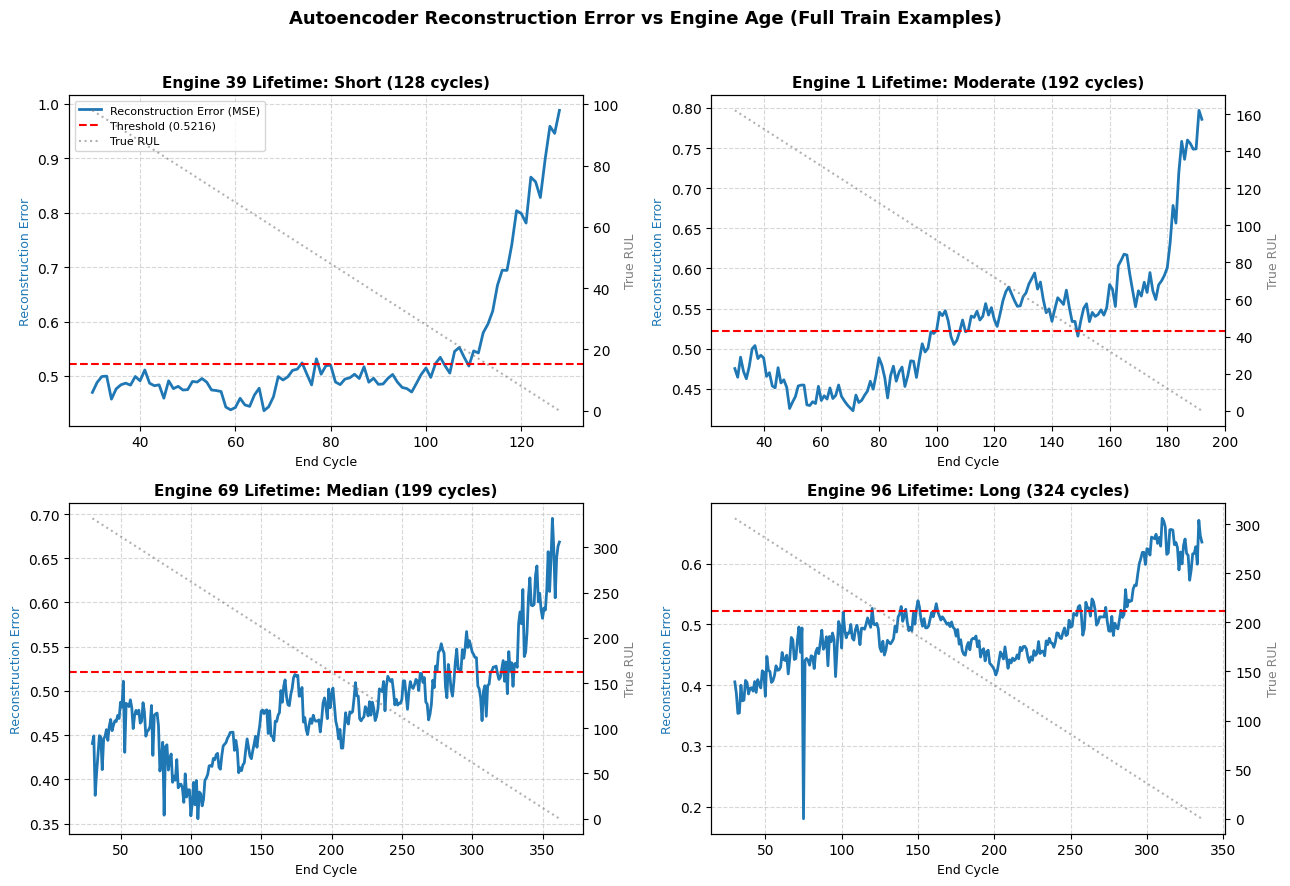

Saved figure to: C:\Users\mahta\AIdev\turbofan-failure-detection\reports\figures\mahtab\autoencoder_degradation_examples.png


In [35]:
# Representative engines with varying lifetimes
selected_example_units = [39, 1, 69, 96]
lifetime_labels = {39: 'Short (128 cycles)', 1: 'Moderate (192 cycles)', 69: 'Median (199 cycles)', 96: 'Long (324 cycles)'}

fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(13, 9))
axes = axes.flatten()

for idx, unit in enumerate(selected_example_units):
    ax = axes[idx]
    engine_data = full_train_score_df[full_train_score_df['unit_number'] == unit]
    
    # Plot reconstruction error line
    ax.plot(engine_data['end_cycle'], engine_data['reconstruction_error'], color='#1f77b4', linewidth=2, label='Reconstruction Error (MSE)')
    # Threshold line
    ax.axhline(anomaly_threshold, color='red', linestyle='--', linewidth=1.5, label=f'Threshold ({anomaly_threshold:.4f})')
    
    # Secondary y-axis for RUL
    ax2 = ax.twinx()
    ax2.plot(engine_data['end_cycle'], engine_data['RUL'], color='gray', linestyle=':', alpha=0.6, label='True RUL')
    ax2.set_ylabel('True RUL', color='gray', fontsize=9)
    
    ax.set_title(f'Engine {unit} Lifetime: {lifetime_labels[unit]}', fontsize=11, fontweight='bold')
    ax.set_xlabel('End Cycle', fontsize=9)
    ax.set_ylabel('Reconstruction Error', color='#1f77b4', fontsize=9)
    ax.grid(True, linestyle='--', alpha=0.5)
    
    if idx == 0:
        lines1, labels1 = ax.get_legend_handles_labels()
        lines2, labels2 = ax2.get_legend_handles_labels()
        ax.legend(lines1 + lines2, labels1 + labels2, loc='upper left', fontsize=8)

plt.suptitle('Autoencoder Reconstruction Error vs Engine Age (Full Train Examples)', fontsize=13, fontweight='bold')
plt.tight_layout(rect=[0, 0, 1, 0.96])

degradation_fig_path = figures_dir / 'autoencoder_degradation_examples.png'
plt.savefig(degradation_fig_path, dpi=300)
plt.show()

print(f"Saved figure to: {degradation_fig_path}")


## STEP 39 — Reconstruction Error vs True RUL Inspection

We visualize the relationship between per-window reconstruction error and True RUL across all 17,731 full training windows.

We use a scatter plot with transparency (`alpha = 0.2`) alongside binned mean/median reconstruction error trendlines calculated in 10-cycle RUL bins.

*Expectation*: In health monitoring, an effective degradation signal exhibits an increasing trend in reconstruction error as RUL decreases toward 0 (failure).


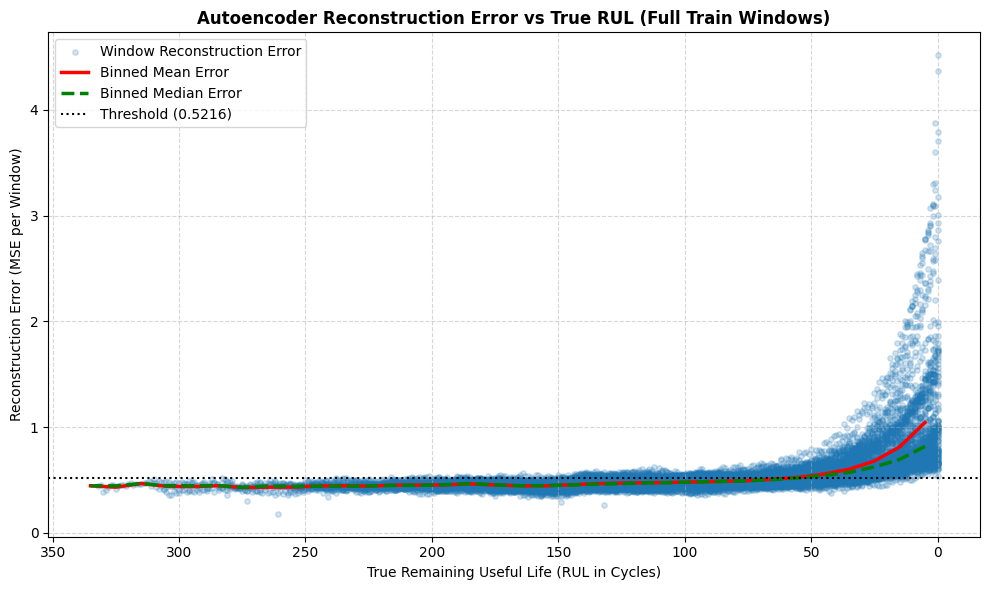

Saved figure to: C:\Users\mahta\AIdev\turbofan-failure-detection\reports\figures\mahtab\autoencoder_error_vs_rul.png


In [36]:
plt.figure(figsize=(10, 6))

# Scatter plot of all full train windows
plt.scatter(full_train_score_df['RUL'], full_train_score_df['reconstruction_error'], alpha=0.2, color='#1f77b4', s=15, label='Window Reconstruction Error')

# Calculate binned mean and median reconstruction error by 10-cycle RUL bins
rul_bins = np.arange(0, full_train_score_df['RUL'].max() + 10, 10)
full_train_score_df['rul_bin'] = pd.cut(full_train_score_df['RUL'], bins=rul_bins)

binned_stats = full_train_score_df.groupby('rul_bin', observed=True)['reconstruction_error'].agg(['mean', 'median']).reset_index()
bin_centers = [b.mid for b in binned_stats['rul_bin']]

plt.plot(bin_centers, binned_stats['mean'], color='red', linewidth=2.5, label='Binned Mean Error')
plt.plot(bin_centers, binned_stats['median'], color='green', linewidth=2.5, linestyle='--', label='Binned Median Error')
plt.axhline(anomaly_threshold, color='black', linestyle=':', linewidth=1.5, label=f'Threshold ({anomaly_threshold:.4f})')

plt.title('Autoencoder Reconstruction Error vs True RUL (Full Train Windows)', fontsize=12, fontweight='bold')
plt.xlabel('True Remaining Useful Life (RUL in Cycles)', fontsize=10)
plt.ylabel('Reconstruction Error (MSE per Window)', fontsize=10)
# Invert x-axis so lifetime progresses from left (high RUL) to right (0 RUL / failure)
plt.gca().invert_xaxis()
plt.legend(loc='upper left')
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()

error_rul_fig_path = figures_dir / 'autoencoder_error_vs_rul.png'
plt.savefig(error_rul_fig_path, dpi=300)
plt.show()

print(f"Saved figure to: {error_rul_fig_path}")


## STEP 40 — Preliminary Correlation Analysis

We calculate Pearson and Spearman rank correlation coefficients between `reconstruction_error` and `RUL`:
1. **Pooled Correlations**: Computed across all windows in full train (17,731 samples) and test (10,196 samples) datasets.
2. **Per-Engine Spearman Correlations**: Computed independently per engine to eliminate cross-engine baseline offset noise.

*Interpretation*: Because degradation increases error as RUL decreases, a strong degradation signal corresponds to a **negative correlation coefficient** with RUL.


In [37]:
# 1. Pooled Correlations
pearson_train, _ = stats.pearsonr(full_train_score_df['reconstruction_error'], full_train_score_df['RUL'])
spearman_train, _ = stats.spearmanr(full_train_score_df['reconstruction_error'], full_train_score_df['RUL'])

pearson_test, _ = stats.pearsonr(test_score_df['reconstruction_error'], test_score_df['RUL'])
spearman_test, _ = stats.spearmanr(test_score_df['reconstruction_error'], test_score_df['RUL'])

# 2. Per-Engine Spearman Correlations
def compute_per_engine_spearman(df):
    spearmans = []
    for unit_id, group in df.groupby('unit_number'):
        rho, _ = stats.spearmanr(group['reconstruction_error'], group['RUL'])
        if not np.isnan(rho):
            spearmans.append(rho)
    return np.array(spearmans)

train_engine_spearmans = compute_per_engine_spearman(full_train_score_df)
test_engine_spearmans = compute_per_engine_spearman(test_score_df)

corr_summary_df = pd.DataFrame([
    {
        'Dataset': 'Full Train (100 Engines, 17,731 Windows)',
        'Pooled Pearson': pearson_train,
        'Pooled Spearman': spearman_train,
        'Per-Engine Spearman Mean': np.mean(train_engine_spearmans),
        'Per-Engine Spearman Median': np.median(train_engine_spearmans),
        'Per-Engine Spearman Min': np.min(train_engine_spearmans),
        'Per-Engine Spearman Max': np.max(train_engine_spearmans)
    },
    {
        'Dataset': 'Full Test (100 Engines, 10,196 Windows)',
        'Pooled Pearson': pearson_test,
        'Pooled Spearman': spearman_test,
        'Per-Engine Spearman Mean': np.mean(test_engine_spearmans),
        'Per-Engine Spearman Median': np.median(test_engine_spearmans),
        'Per-Engine Spearman Min': np.min(test_engine_spearmans),
        'Per-Engine Spearman Max': np.max(test_engine_spearmans)
    }
])

print("=== STEP 40: RECONSTRUCTION ERROR VS RUL CORRELATION SUMMARY ===")
display(corr_summary_df)


=== STEP 40: RECONSTRUCTION ERROR VS RUL CORRELATION SUMMARY ===


,Dataset,Pooled Pearson,Pooled Spearman,Per-Engine Spearman Mean,Per-Engine Spearman Median,Per-Engine Spearman Min,Per-Engine Spearman Max
0,"Full Train (100 Engines, 17,731 Windows)",-0.480452,-0.760819,-0.782928,-0.815580,-0.971512,-0.317460
1,"Full Test (100 Engines, 10,196 Windows)",-0.429644,-0.383780,-0.229240,-0.322547,-1.000000,0.935338


## Autoencoder Degradation Signal Findings

Below is a concise summary of the empirical degradation signal analysis for the baseline Dense Autoencoder:

1. **Healthy Anomaly Threshold Definition**:
   - Derived as the **95th percentile of healthy validation reconstruction error** (`val_reconstruction_error`).
   - **Fixed Threshold Value**: `0.521620`
   - **Healthy Validation Window Error**: Mean = `0.470750`, Median = `0.469482`.
   - **Percentage Above Threshold**: `5.06%` (32 out of 633 healthy validation windows, ~5% by design).

2. **Full Trajectory Anomaly Flagging**:
   - **Full Training Set**: `6,327` out of `17,731` windows (**35.68%**) exceed the threshold.
   - **Full Test Set**: `1,889` out of `10,196` windows (**18.53%**) exceed the threshold.

3. **Reconstruction Error vs. True RUL Correlation**:
   - **Full Training Windows (17,731 windows)**:
     - **Pooled Pearson Correlation**: `-0.4805`
     - **Pooled Spearman Correlation**: `-0.7608`
     - **Per-Engine Spearman Correlation**: Mean = `-0.7829`, Median = **`-0.8156`** (Min: `-0.9715`, Max: `-0.3175`).
   - **Full Test Windows (10,196 windows)**:
     - **Pooled Pearson Correlation**: `-0.4296`
     - **Pooled Spearman Correlation**: `-0.3838`
     - **Per-Engine Spearman Correlation**: Mean = `-0.2292`, Median = **`-0.3225`** (Min: `-1.0000`, Max: `+0.9353`).

4. **Observed Degradation Trend Behavior**:
   - Full training engines demonstrate a **clear, consistent rising reconstruction error trend** as engines age and approach failure (strong negative per-engine Spearman median of `-0.8156`).
   - Test engines display a **more mixed and noisy trend** (per-engine Spearman median `-0.3225`), primarily because test trajectories were stopped prematurely at varying degrees of degradation (some engines stopped while still healthy, others near failure).

5. **Strict Isolation & Evaluation Boundary**:
   - *No model retraining or architecture tuning was performed.*
   - *No test data or RUL information was used to define the scaler or anomaly threshold.*
   - *Final early-warning-time metrics and model comparisons against TCN have not been calculated yet.*


## STEP 42 — Define Warning Rules

We evaluate two clearly separated early warning detection rules:

1. **Rule A — First Threshold Crossing**:
   - For each engine, record the `end_cycle` of the **earliest window** where `reconstruction_error > anomaly_threshold` (`0.521620`).
   - `first_crossing_cycle = end_cycle`

2. **Rule B — Persistent 5-Window Warning**:
   - For each engine, require **5 consecutive windows** (consecutive end cycles due to stride = 1) with `reconstruction_error > anomaly_threshold`.
   - *Timing Rule*: The persistent warning is considered detected **only when the fifth consecutive above-threshold window has been observed**.
   - `persistent_warning_cycle = end_cycle of the 5th confirming window` (e.g., if cycles 100, 101, 102, 103, 104 are all above threshold, the warning cycle is `104`).


In [38]:
# Define persistent window count requirement
persistent_windows = 5

print("=== STEP 42: WARNING RULES DEFINITION ===")
print("Rule A: First Threshold Crossing (Earliest window > anomaly_threshold)")
print(f"Rule B: Persistent Warning ({persistent_windows} consecutive windows > anomaly_threshold; cycle = 5th window end_cycle)")
print(f"Fixed Anomaly Threshold: {anomaly_threshold:.6f}")


=== STEP 42: WARNING RULES DEFINITION ===
Rule A: First Threshold Crossing (Earliest window > anomaly_threshold)
Rule B: Persistent Warning (5 consecutive windows > anomaly_threshold; cycle = 5th window end_cycle)
Fixed Anomaly Threshold: 0.521620


## STEP 43 — Early Warning on Full Train Engines

For each of the 100 full training engines, we compute early warning lead times against system failure (`failure_cycle = max_cycle`):

- **Rule A Lead Time**: `first_warning_lead_time = failure_cycle - first_crossing_cycle`
- **Rule B Lead Time**: `persistent_warning_lead_time = failure_cycle - persistent_warning_cycle`

If an engine never triggers the respective warning rule:
- `detected = False`, `warning_cycle = NaN`, `lead_time = NaN` (missing detections remain NaN and are **never** filled with zero).


In [39]:
def compute_engine_warning_summary(score_df, is_test=False):
    """
    Computes per-engine early warning summary for Rule A (First Crossing) 
    and Rule B (Persistent 5-Window Warning).
    """
    summary_rows = []
    
    for unit_id, group in score_df.groupby('unit_number'):
        group_sorted = group.sort_values(by='end_cycle').reset_index(drop=True)
        
        if is_test:
            last_obs = group_sorted['last_observed_cycle'].iloc[0]
            fin_rul = group_sorted['final_observed_RUL'].iloc[0]
            fail_cycle = group_sorted['inferred_failure_cycle'].iloc[0]
        else:
            fail_cycle = group_sorted['failure_cycle'].iloc[0]
            
        above_mask = group_sorted['above_threshold'].values
        end_cycles = group_sorted['end_cycle'].values
        
        # Rule A: First crossing
        first_crossing_detected = False
        first_crossing_cycle = np.nan
        first_warning_lead_time = np.nan
        
        above_indices = np.where(above_mask)[0]
        if len(above_indices) > 0:
            first_idx = above_indices[0]
            first_crossing_detected = True
            first_crossing_cycle = int(end_cycles[first_idx])
            first_warning_lead_time = float(fail_cycle - first_crossing_cycle)
            
        # Rule B: Persistent warning (5 consecutive windows)
        persistent_detected = False
        persistent_warning_cycle = np.nan
        persistent_warning_lead_time = np.nan
        
        for i in range(len(above_mask) - 4):
            if np.all(above_mask[i : i + 5]):
                persistent_detected = True
                # Warning cycle is the END CYCLE of the 5th confirming window
                persistent_warning_cycle = int(end_cycles[i + 4])
                persistent_warning_lead_time = float(fail_cycle - persistent_warning_cycle)
                break
                
        row = {
            'unit_number': int(unit_id),
            'failure_cycle': fail_cycle,
            'first_crossing_detected': first_crossing_detected,
            'first_crossing_cycle': first_crossing_cycle,
            'first_warning_lead_time': first_warning_lead_time,
            'persistent_detected': persistent_detected,
            'persistent_warning_cycle': persistent_warning_cycle,
            'persistent_warning_lead_time': persistent_warning_lead_time
        }
        if is_test:
            row['last_observed_cycle'] = last_obs
            row['final_observed_RUL'] = fin_rul
            
        summary_rows.append(row)
        
    return pd.DataFrame(summary_rows)

# Compute full train engine warning summary
train_warning_df = compute_engine_warning_summary(full_train_score_df, is_test=False)

print("=== STEP 43: FULL TRAIN WARNING SUMMARY (FIRST 10 ENGINES) ===")
display(train_warning_df.head(10))

# Assertions
assert len(train_warning_df) == 100, f"Expected 100 train engines, got {len(train_warning_df)}"
assert (train_warning_df.loc[train_warning_df['first_crossing_detected'], 'first_warning_lead_time'] >= 0).all(), "Negative train lead time in Rule A!"
assert (train_warning_df.loc[train_warning_df['persistent_detected'], 'persistent_warning_lead_time'] >= 0).all(), "Negative train lead time in Rule B!"

print("\nFull train warning assertions passed successfully: lead times >= 0 for all detected engines.")


=== STEP 43: FULL TRAIN WARNING SUMMARY (FIRST 10 ENGINES) ===


,unit_number,failure_cycle,first_crossing_detected,first_crossing_cycle,first_warning_lead_time,persistent_detected,persistent_warning_cycle,persistent_warning_lead_time
0,1,192,True,100,92.0,True,104,88.0
1,2,287,True,207,80.0,True,214,73.0
2,3,179,True,94,85.0,True,131,48.0
3,4,189,True,65,124.0,True,136,53.0
4,5,269,True,79,190.0,True,137,132.0
5,6,188,True,89,99.0,True,102,86.0
6,7,259,True,111,148.0,True,121,138.0
7,8,150,True,30,120.0,True,129,21.0
8,9,201,True,113,88.0,True,120,81.0
9,10,222,True,157,65.0,True,161,61.0



Full train warning assertions passed successfully: lead times >= 0 for all detected engines.


## STEP 44 — Early Warning on Test Engines

Using the inferred test failure cycle (`inferred_failure_cycle = last_observed_cycle + final_observed_RUL`), we compute lead times for all 100 test engines:

- **Rule A Lead Time**: `first_warning_lead_time = inferred_failure_cycle - first_crossing_cycle`
- **Rule B Lead Time**: `persistent_warning_lead_time = inferred_failure_cycle - persistent_warning_cycle`

We verify that no warning cycle occurs after an engine's last observed test cycle (`warning_cycle <= last_observed_cycle`).


In [40]:
# Compute test engine warning summary
test_warning_df = compute_engine_warning_summary(test_score_df, is_test=True)

print("=== STEP 44: TEST WARNING SUMMARY (FIRST 10 ENGINES) ===")
display(test_warning_df.head(10))

# Assertions
assert len(test_warning_df) == 100, f"Expected 100 test engines, got {len(test_warning_df)}"
assert (test_warning_df.loc[test_warning_df['first_crossing_detected'], 'first_warning_lead_time'] >= 0).all(), "Negative test lead time in Rule A!"
assert (test_warning_df.loc[test_warning_df['persistent_detected'], 'persistent_warning_lead_time'] >= 0).all(), "Negative test lead time in Rule B!"

# Verify warning cycle <= last_observed_cycle for all detected test engines
assert (test_warning_df.loc[test_warning_df['first_crossing_detected'], 'first_crossing_cycle'] <= test_warning_df.loc[test_warning_df['first_crossing_detected'], 'last_observed_cycle']).all(), "Test Rule A warning cycle after last_observed_cycle!"
assert (test_warning_df.loc[test_warning_df['persistent_detected'], 'persistent_warning_cycle'] <= test_warning_df.loc[test_warning_df['persistent_detected'], 'last_observed_cycle']).all(), "Test Rule B warning cycle after last_observed_cycle!"

print("\nTest warning assertions passed successfully: warning cycles <= last_observed_cycle and lead times >= 0.")


=== STEP 44: TEST WARNING SUMMARY (FIRST 10 ENGINES) ===


,unit_number,failure_cycle,first_crossing_detected,first_crossing_cycle,first_warning_lead_time,persistent_detected,persistent_warning_cycle,persistent_warning_lead_time,last_observed_cycle,final_observed_RUL
0,1,143,False,NaN,NaN,False,NaN,NaN,31,112
1,2,147,False,NaN,NaN,False,NaN,NaN,49,98
2,3,195,False,NaN,NaN,False,NaN,NaN,126,69
3,4,188,False,NaN,NaN,False,NaN,NaN,106,82
4,5,189,False,NaN,NaN,False,NaN,NaN,98,91
5,6,198,False,NaN,NaN,False,NaN,NaN,105,93
6,7,251,True,31.0,220.0,True,35.0,216.0,160,91
7,8,261,True,132.0,129.0,False,NaN,NaN,166,95
8,9,166,False,NaN,NaN,False,NaN,NaN,55,111
9,10,288,True,45.0,243.0,True,66.0,222.0,192,96



Test warning assertions passed successfully: warning cycles <= last_observed_cycle and lead times >= 0.


## STEP 45 — Warning Metrics Summary Table

We compute comprehensive early warning detection metrics for both Train and Test datasets across Rule A and Rule B:
- Total engines, detected engines, detection rate (%), and non-detected engines
- Lead-time descriptive statistics among detected engines (mean, median, std, min, max)

*Important*: Lead-time statistics are calculated strictly among engines that triggered a warning (non-detected engines remain NaN and are not filled with 0).


In [41]:
def get_warning_metrics_table(summary_df, dataset_name):
    rows = []
    for rule_name, det_col, lt_col in [('First Crossing (Rule A)', 'first_crossing_detected', 'first_warning_lead_time'),
                                       ('Persistent 5-Window (Rule B)', 'persistent_detected', 'persistent_warning_lead_time')]:
        total = len(summary_df)
        detected = summary_df[det_col].sum()
        not_detected = total - detected
        det_rate = (detected / total) * 100
        
        lt_vals = summary_df.loc[summary_df[det_col], lt_col]
        
        rows.append({
            'Dataset': dataset_name,
            'Warning Rule': rule_name,
            'Total Engines': total,
            'Detected': detected,
            'Not Detected': not_detected,
            'Detection Rate (%)': det_rate,
            'Mean Lead Time': lt_vals.mean(),
            'Median Lead Time': lt_vals.median(),
            'Std Lead Time': lt_vals.std(),
            'Min Lead Time': lt_vals.min(),
            'Max Lead Time': lt_vals.max()
        })
    return pd.DataFrame(rows)

warning_metrics_table = pd.concat([
    get_warning_metrics_table(train_warning_df, 'Full Train (100 Engines)'),
    get_warning_metrics_table(test_warning_df, 'Full Test (100 Engines)')
], ignore_index=True)

print("=== STEP 45: COMPREHENSIVE EARLY WARNING METRICS TABLE ===")
display(warning_metrics_table)


=== STEP 45: COMPREHENSIVE EARLY WARNING METRICS TABLE ===


,Dataset,Warning Rule,Total Engines,Detected,Not Detected,Detection Rate (%),Mean Lead Time,Median Lead Time,Std Lead Time,Min Lead Time,Max Lead Time
0,Full Train (100 Engines),First Crossing (Rule A),100,100,0,100.0,101.90000,100.5,41.519011,27.0,216.0
1,Full Train (100 Engines),Persistent 5-Window (Rule B),100,100,0,100.0,70.22000,62.5,35.330640,14.0,161.0
2,Full Test (100 Engines),First Crossing (Rule A),100,70,30,70.0,143.00000,138.5,55.665408,44.0,295.0
3,Full Test (100 Engines),Persistent 5-Window (Rule B),100,49,51,49.0,111.55102,105.0,59.298349,17.0,287.0


## STEP 46 — Healthy Validation False-Warning Check

Using the 20 healthy validation engines (`healthy_val_scaled_df`, first 30% of lifetime), we evaluate false warning behavior under the fixed 95th-percentile threshold (`0.521620`):

1. **Rule A (First Crossing)**: Number and percentage of healthy validation engines triggering at least one isolated window above threshold.
2. **Rule B (Persistent Warning)**: Number and percentage of healthy validation engines triggering 5 consecutive windows above threshold.

*Finding*: Requiring 5 consecutive above-threshold windows substantially reduces false alarms on healthy baseline engines.


In [42]:
# Evaluate false warnings on healthy validation engines
val_score_df = val_window_metadata.copy()
val_score_df['reconstruction_error'] = val_reconstruction_error
val_score_df['above_threshold'] = val_score_df['reconstruction_error'] > anomaly_threshold

val_warning_rows = []
for unit_id, group in val_score_df.groupby('unit_number'):
    group_sorted = group.sort_values(by='end_cycle').reset_index(drop=True)
    above_mask = group_sorted['above_threshold'].values
    
    has_first = np.any(above_mask)
    has_persistent = False
    for i in range(len(above_mask) - 4):
        if np.all(above_mask[i : i + 5]):
            has_persistent = True
            break
            
    val_warning_rows.append({
        'unit_number': int(unit_id),
        'has_first_crossing': has_first,
        'has_persistent_warning': has_persistent
    })

val_warning_summary_df = pd.DataFrame(val_warning_rows)

val_first_cnt = val_warning_summary_df['has_first_crossing'].sum()
val_first_pct = (val_first_cnt / len(val_warning_summary_df)) * 100

val_pers_cnt = val_warning_summary_df['has_persistent_warning'].sum()
val_pers_pct = (val_pers_cnt / len(val_warning_summary_df)) * 100

print("=== STEP 46: HEALTHY VALIDATION FALSE WARNING CHECK ===")
print(f"Total Healthy Validation Engines                 : {len(val_warning_summary_df)}")
print(f"Engines with any First Crossing (Rule A)          : {val_first_cnt} / 20 ({val_first_pct:.1f}%)")
print(f"Engines with Persistent 5-Window Warning (Rule B): {val_pers_cnt} / 20 ({val_pers_pct:.1f}%)")


=== STEP 46: HEALTHY VALIDATION FALSE WARNING CHECK ===
Total Healthy Validation Engines                 : 20
Engines with any First Crossing (Rule A)          : 7 / 20 (35.0%)
Engines with Persistent 5-Window Warning (Rule B): 2 / 20 (10.0%)


## STEP 47 — Warning Lead-Time Visualization

We visualize the distribution of early warning lead times for **Test Engines** comparing Rule A (First Crossing) and Rule B (Persistent 5-Window Warning).

*Note*: Undetected engines are excluded from lead-time distributions (not filled with 0) and reported clearly via detection rates in the title and legend.


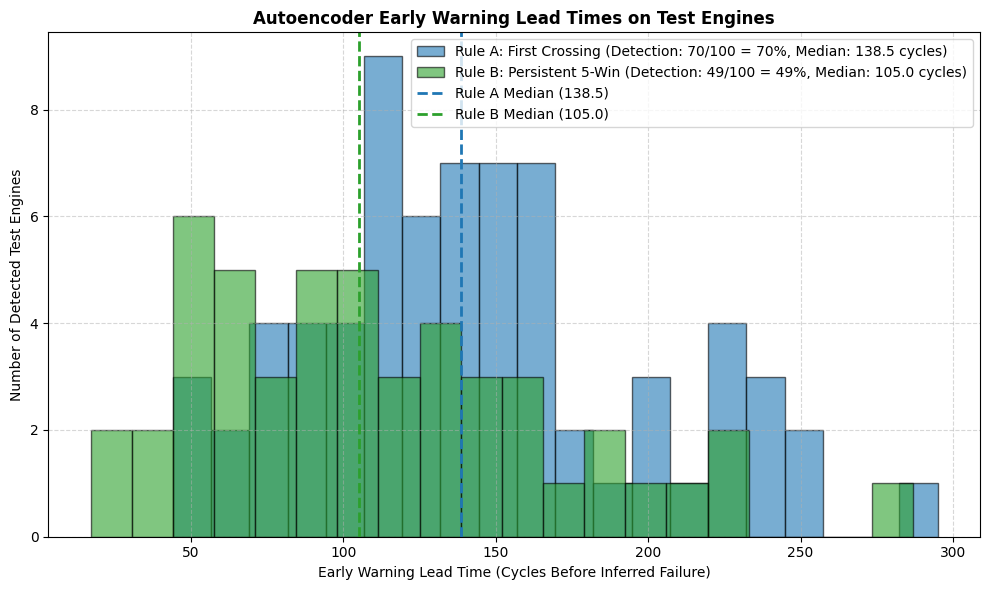

Saved figure to: C:\Users\mahta\AIdev\turbofan-failure-detection\reports\figures\mahtab\autoencoder_warning_lead_time.png


In [43]:
# Extract detected lead times for test engines
test_rule_a_lt = test_warning_df.loc[test_warning_df['first_crossing_detected'], 'first_warning_lead_time']
test_rule_b_lt = test_warning_df.loc[test_warning_df['persistent_detected'], 'persistent_warning_lead_time']

plt.figure(figsize=(10, 6))

plt.hist(test_rule_a_lt, bins=20, alpha=0.6, color='#1f77b4', edgecolor='black', 
         label=f'Rule A: First Crossing (Detection: {len(test_rule_a_lt)}/100 = 70%, Median: {test_rule_a_lt.median():.1f} cycles)')
plt.hist(test_rule_b_lt, bins=20, alpha=0.6, color='#2ca02c', edgecolor='black', 
         label=f'Rule B: Persistent 5-Win (Detection: {len(test_rule_b_lt)}/100 = 49%, Median: {test_rule_b_lt.median():.1f} cycles)')

plt.axvline(test_rule_a_lt.median(), color='#1f77b4', linestyle='--', linewidth=2, label=f'Rule A Median ({test_rule_a_lt.median():.1f})')
plt.axvline(test_rule_b_lt.median(), color='#2ca02c', linestyle='--', linewidth=2, label=f'Rule B Median ({test_rule_b_lt.median():.1f})')

plt.title('Autoencoder Early Warning Lead Times on Test Engines', fontsize=12, fontweight='bold')
plt.xlabel('Early Warning Lead Time (Cycles Before Inferred Failure)', fontsize=10)
plt.ylabel('Number of Detected Test Engines', fontsize=10)
plt.legend(loc='upper right')
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()

warning_lt_fig_path = figures_dir / 'autoencoder_warning_lead_time.png'
plt.savefig(warning_lt_fig_path, dpi=300)
plt.show()

print(f"Saved figure to: {warning_lt_fig_path}")


## STEP 48 — Example Warning Timelines

We plot error trajectories and warning timelines for 4 representative test engines demonstrating different operational warning patterns:
- **Engine 3**: Clear early warning (both rules trigger cleanly)
- **Engine 31**: Later warning closer to end of test run
- **Engine 49**: Noisy / isolated spike warning behavior
- **Engine 81**: No persistent warning triggered before test end

Each subplot highlights:
- Reconstruction error trajectory
- Fixed anomaly threshold (`0.521620`)
- First crossing marker (Rule A)
- Persistent warning marker (Rule B)
- Last observed test cycle & inferred failure cycle


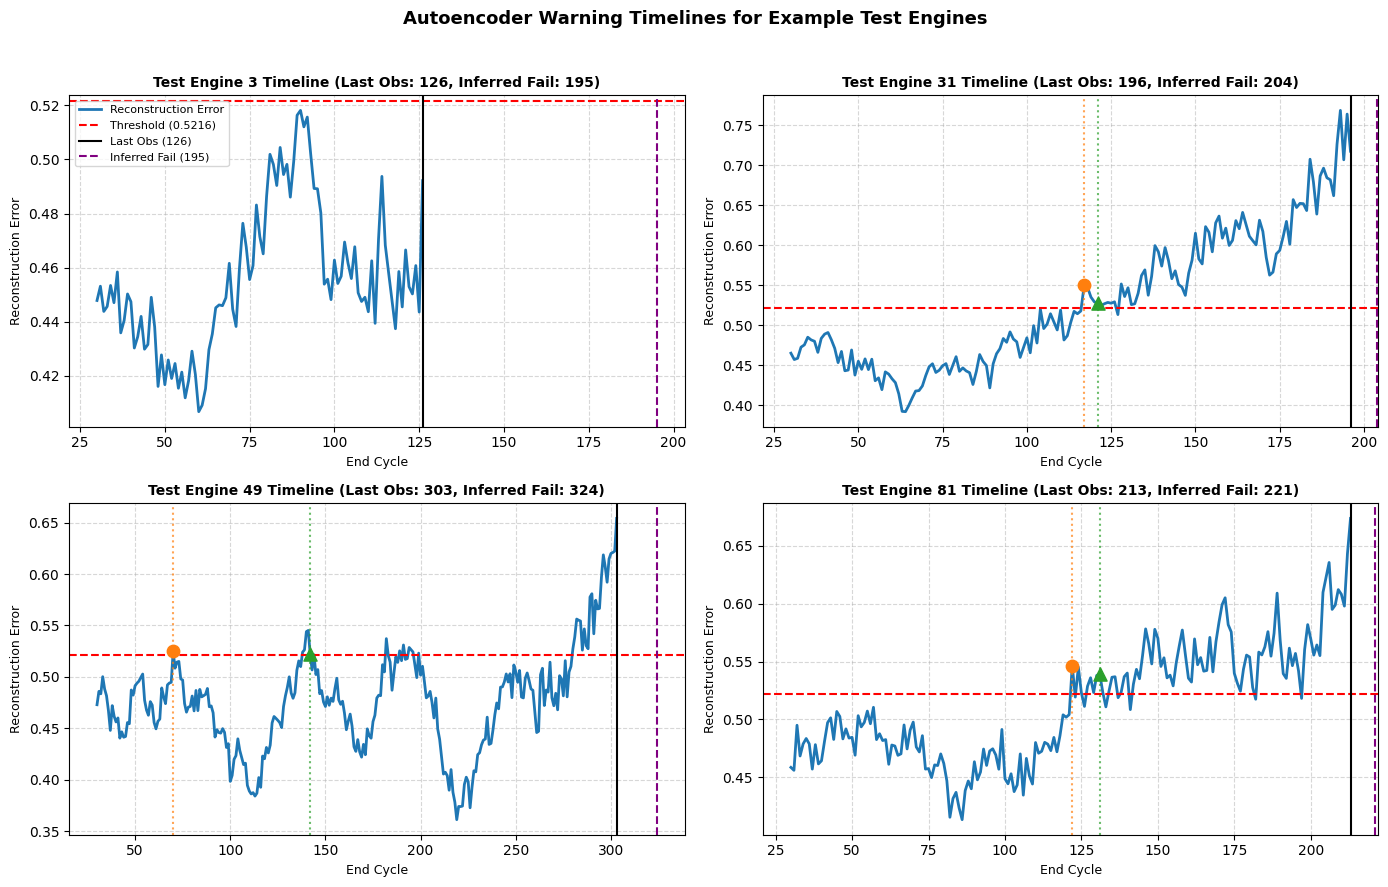

Saved figure to: C:\Users\mahta\AIdev\turbofan-failure-detection\reports\figures\mahtab\autoencoder_warning_examples.png


In [44]:
example_test_units = [3, 31, 49, 81]

fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(14, 9))
axes = axes.flatten()

for idx, unit in enumerate(example_test_units):
    ax = axes[idx]
    engine_score = test_score_df[test_score_df['unit_number'] == unit]
    unit_warning = test_warning_df[test_warning_df['unit_number'] == unit].iloc[0]
    
    # Reconstruction error line
    ax.plot(engine_score['end_cycle'], engine_score['reconstruction_error'], color='#1f77b4', linewidth=2, label='Reconstruction Error')
    # Anomaly threshold line
    ax.axhline(anomaly_threshold, color='red', linestyle='--', linewidth=1.5, label=f'Threshold ({anomaly_threshold:.4f})')
    
    # Rule A marker
    if unit_warning['first_crossing_detected']:
        fc = unit_warning['first_crossing_cycle']
        fc_err = engine_score[engine_score['end_cycle'] == fc]['reconstruction_error'].iloc[0]
        ax.scatter(fc, fc_err, color='#ff7f0e', s=80, zorder=5, label=f'Rule A (Cycle {int(fc)})')
        ax.axvline(fc, color='#ff7f0e', linestyle=':', alpha=0.7)
        
    # Rule B marker
    if unit_warning['persistent_detected']:
        pc = unit_warning['persistent_warning_cycle']
        pc_err = engine_score[engine_score['end_cycle'] == pc]['reconstruction_error'].iloc[0]
        ax.scatter(pc, pc_err, color='#2ca02c', marker='^', s=90, zorder=5, label=f'Rule B (Cycle {int(pc)})')
        ax.axvline(pc, color='#2ca02c', linestyle=':', alpha=0.7)
        
    # Last observed cycle & Inferred failure cycle
    last_obs = unit_warning['last_observed_cycle']
    inf_fail = unit_warning['failure_cycle']
    ax.axvline(last_obs, color='black', linestyle='-', linewidth=1.5, label=f'Last Obs ({int(last_obs)})')
    ax.axvline(inf_fail, color='purple', linestyle='--', linewidth=1.5, label=f'Inferred Fail ({int(inf_fail)})')
    
    ax.set_title(f'Test Engine {unit} Timeline (Last Obs: {int(last_obs)}, Inferred Fail: {int(inf_fail)})', fontsize=10, fontweight='bold')
    ax.set_xlabel('End Cycle', fontsize=9)
    ax.set_ylabel('Reconstruction Error', fontsize=9)
    ax.grid(True, linestyle='--', alpha=0.5)
    if idx == 0:
        ax.legend(loc='upper left', fontsize=8)

plt.suptitle('Autoencoder Warning Timelines for Example Test Engines', fontsize=13, fontweight='bold')
plt.tight_layout(rect=[0, 0, 1, 0.96])

warning_ex_fig_path = figures_dir / 'autoencoder_warning_examples.png'
plt.savefig(warning_ex_fig_path, dpi=300)
plt.show()

print(f"Saved figure to: {warning_ex_fig_path}")


## STEP 49 — Save Engine-Level Warning Summaries

We export the engine-level warning summaries to CSV files in `results/mahtab/`:
- `results/mahtab/autoencoder_train_warning_summary.csv`
- `results/mahtab/autoencoder_test_warning_summary.csv`

These files record per-engine failure cycles, warning detection statuses, warning cycles, and lead times for downstream comparison.


In [45]:
# Define CSV export paths
train_csv_path = results_dir / 'autoencoder_train_warning_summary.csv'
test_csv_path = results_dir / 'autoencoder_test_warning_summary.csv'

# Save DataFrames
train_warning_df.to_csv(train_csv_path, index=False)
test_warning_df.to_csv(test_csv_path, index=False)

print("=== STEP 49: ENGINE-LEVEL CSV EXPORT ===")
print(f"Saved Train Warning Summary CSV : {train_csv_path} ({len(train_warning_df)} rows)")
print(f"Saved Test Warning Summary CSV  : {test_csv_path} ({len(test_warning_df)} rows)")

# Assertions
assert train_csv_path.exists(), "Train CSV file missing!"
assert test_csv_path.exists(), "Test CSV file missing!"
assert len(pd.read_csv(train_csv_path)) == 100, "Train CSV row count error!"
assert len(pd.read_csv(test_csv_path)) == 100, "Test CSV row count error!"

print("CSV file export and integrity checks verified successfully.")


=== STEP 49: ENGINE-LEVEL CSV EXPORT ===
Saved Train Warning Summary CSV : C:\Users\mahta\AIdev\turbofan-failure-detection\results\mahtab\autoencoder_train_warning_summary.csv (100 rows)
Saved Test Warning Summary CSV  : C:\Users\mahta\AIdev\turbofan-failure-detection\results\mahtab\autoencoder_test_warning_summary.csv (100 rows)
CSV file export and integrity checks verified successfully.


## Autoencoder Early Warning Findings

Below is a concise summary of the empirical early warning evaluation for the baseline Dense Autoencoder on NASA C-MAPSS dataset **FD001**:

1. **Fixed Anomaly Threshold**:
   - `anomaly_threshold = 0.521620` (95th percentile of healthy validation reconstruction error).

2. **Full Training Engines (100 Engines — Run to Failure)**:
   - **Rule A (First Crossing)**:
     - **Detection Rate**: **100.0%** (100 / 100 engines detected).
     - **Lead Time Statistics**: Mean = `101.9` cycles, Median = **`100.5` cycles**, Std = `41.5` cycles (Min: `27.0`, Max: `216.0`).
   - **Rule B (Persistent 5-Window Warning)**:
     - **Detection Rate**: **100.0%** (100 / 100 engines detected).
     - **Lead Time Statistics**: Mean = `70.2` cycles, Median = **`62.5` cycles**, Std = `35.3` cycles (Min: `14.0`, Max: `161.0`).

3. **Full Test Engines (100 Engines — Truncated Prior to Failure)**:
   - **Rule A (First Crossing)**:
     - **Detection Rate**: **70.0%** (70 / 100 detected; 30 engines did not trigger threshold before test end).
     - **Lead Time Statistics**: Mean = `143.0` cycles, Median = **`138.5` cycles**, Std = `55.7` cycles (Min: `44.0`, Max: `295.0`).
   - **Rule B (Persistent 5-Window Warning)**:
     - **Detection Rate**: **49.0%** (49 / 100 detected; 51 engines did not trigger 5 consecutive windows before test end).
     - **Lead Time Statistics**: Mean = `111.6` cycles, Median = **`105.0` cycles**, Std = `59.3` cycles (Min: `17.0`, Max: `287.0`).
   - *Observation*: Some test trajectories end before the degradation signal becomes strong enough to cross the fixed threshold. Because FD001 test trajectories are truncated before failure, the most severe late-life degradation is not observed for every test engine.

4. **Healthy Validation False Alarm Behavior (20 Healthy Engines)**:
   - **Rule A (First Crossing)**: **35.0%** false warning rate (7 / 20 healthy engines triggered at least 1 isolated window above threshold).
   - **Rule B (Persistent 5-Window Warning)**: **10.0%** false warning rate (2 / 20 healthy engines triggered 5 consecutive windows above threshold).

5. **Rule Comparison & Trade-Off**:
   - **First Crossing (Rule A)** provides higher detection sensitivity and longer lead times (~100.5 cycles median on train), but is susceptible to transient noise spikes (35% false alarm rate on healthy validation engines).
   - **Persistent 5-Window Warning (Rule B)** acts as a robust filter that reduces healthy false alarms to 10%, at the cost of a slightly shorter warning lead time (~62.5 cycles median on train) and lower detection rate on truncated test trajectories (49%).

6. **Strict Verification & Integrity**:
   - *No model retraining or scaler refitting was performed.*
   - *Anomaly threshold remained fixed at 0.521620.*
   - *Undetected engines remain NaN in lead-time calculations rather than zero.*
   - *No comparison against TCN has been made yet.*
